In [ ]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [ ]:
#hide
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

# Заглянем внутрь: Обучение классификатора цифр.

В главе 2 мы увидели, как на практике обучаются различные модели. Теперь давайте заглянем "под капот" и посмотрим, что именно происходит. Мы начнем с использования компьютерного зрения, чтобы представить основные инструменты и концепции глубокого обучения.

Более конкретно, мы обсудим роли массивов и тензоров, а также технику "трансляции" (broadcasting), мощный способ их использования. Мы объясним стохастический градиентный спуск (SGD), механизм обучения путем автоматической корректировки весов. Мы рассмотрим выбор функции потерь для нашей базовой задачи классификации и роль мини-пакетов. Мы также опишем математические операции, которые выполняет простая нейронная сеть. Наконец, мы соберем все эти элементы вместе.

В будущих главах мы более подробно рассмотрим другие области применения и увидим, как эти концепции и инструменты распространяются. Но эта глава посвящена заложению фундамента. Откровенно говоря, это одна из самых сложных глав, поскольку все эти концепции взаимосвязаны. Как и в арке, все элементы должны быть на своих местах, чтобы конструкция была устойчивой. Также, как и арка, после того, как все собрано, получается мощная структура, которая может поддерживать другие элементы. Но для сборки требуется определенное терпение.

Начнем. Первый шаг – это рассмотреть, как изображения представляются в компьютере.

## Пиксели: Основы компьютерного зрения.


Чтобы понять, что происходит в модели компьютерного зрения, нам сначала необходимо разобраться в том, как компьютеры обрабатывают изображения. Для наших экспериментов мы будем использовать один из самых известных наборов данных в области компьютерного зрения, [MNIST](https://en.wikipedia.org/wiki/MNIST_database). MNIST содержит изображения рукописных цифр, собранные Национальным институтом стандартов и технологий и объединенные в набор данных для машинного обучения Яном Лекуном и его коллегами. Лекун использовал MNIST в 1998 году в [Lenet-5](http://yann.lecun.com/exdb/lenet/), первой компьютерной системе, продемонстрировавшей практически полезное распознавание последовательностей рукописных цифр. Это было одно из важнейших достижений в истории искусственного интеллекта.

## Боковая панель: Упорство и глубокое обучение.


История глубокого обучения – это история упорства и настойчивости небольшой группы преданных исследователей. После первых надежд (и, конечно, ажиотажа!), нейронные сети потеряли популярность в 1990-х и 2000-х годах, и лишь немногие исследователи продолжали пытаться сделать их эффективными. Трое из них, Ян Лекун, Йошуа Бенджио и Джеффри Хинтон, были удостоены высшей награды в области компьютерных наук, премии Тьюринга (обычно называемой "Нобелевской премией компьютерных наук"), в 2018 году, несмотря на глубокий скептицизм и отсутствие интереса со стороны широкого сообщества специалистов в области машинного обучения и статистики.

Джефффри Хинтон рассказывал о том, как даже научные работы, демонстрирующие значительно лучшие результаты, чем все, что было опубликовано ранее, отклонялись ведущими журналами и конференциями, просто потому, что в них использовались нейронные сети. Работы Яна Лекуна, посвященные сверточным нейронным сетям, которые мы изучим в следующем разделе, показали, что эти модели могут распознавать рукописный текст – что раньше казалось невозможным. Однако этот прорыв был проигнорирован большинством исследователей, хотя он и использовался в коммерческих целях для распознавания 10% чеков в США!

Помимо этих трех лауреатов премии Тьюринга, существует множество других исследователей, которые боролись, чтобы привести нас к тому, где мы находимся сегодня. Например, Юрген Шмидхубер (которого многие считают, что ему следовало разделить премию Тьюринга) разработал множество важных идей, в том числе работал со своим студентом Сеппом Хохрейтером над архитектурой LSTM (широко используемой для распознавания речи и других задач моделирования текста, и применяемой в примере IMDb в разделе "<<chapter_intro>>"). Возможно, самое главное, Пол Вербос в 1974 году изобрел алгоритм обратного распространения ошибки для нейронных сетей, который представлен в этой главе и используется повсеместно для обучения нейронных сетей ([Werbos 1994](https://books.google.com/books/about/The_Roots_of_Backpropagation.html?id=WdR3OOM2gBwC)). Его разработка была практически полностью проигнорирована в течение десятилетий, но сегодня она считается одним из важнейших оснований современной искусственного интеллекта.

Здесь есть урок для всех нас! На вашем пути в области глубокого обучения вы столкнетесь с множеством препятствий, как технических, так и (что еще сложнее) создаваемых людьми вокруг вас, которые не верят в ваш успех. Существует один *безошибочный* способ потерпеть неудачу, и это – перестать пытаться. Мы видим, что единственное, что объединяет всех студентов fast.ai, ставших специалистами мирового класса, – это их невероятная настойчивость.


## Конец боковой панели


В этом вводном уроке мы попробуем создать модель, которая сможет классифицировать любое изображение как цифру "3" или "7". Поэтому давайте скачаем пример набора данных MNIST, который содержит изображения только этих цифр:


In [ ]:
path = untar_data(URLs.MNIST_SAMPLE)

In [ ]:
#hide
Path.BASE_PATH = path

Мы можем увидеть, что находится в этой директории, используя команду `ls`, которая была добавлена библиотекой fastai. Этот метод возвращает объект специального класса fastai под названием `L`, который обладает всей функциональностью встроенного списка Python (`list`), а также множеством дополнительных возможностей. Одна из полезных функций этого объекта заключается в том, что при выводе он отображает количество элементов, а затем переходит к перечислению самих элементов (если элементов больше 10, он показывает только несколько первых).

In [ ]:
path.ls()

(#9) [Path('cleaned.csv'),Path('item_list.txt'),Path('trained_model.pkl'),Path('models'),Path('valid'),Path('labels.csv'),Path('export.pkl'),Path('history.csv'),Path('train')]

Набор данных MNIST следует общепринятой структуре для наборов данных машинного обучения: отдельные папки для обучающего набора и набора для проверки (и/или тестового набора). Давайте посмотрим, что находится внутри обучающего набора:


In [ ]:
(path/'train').ls()

(#2) [Path('train/7'),Path('train/3')]

Здесь есть папка с файлами, содержащими число "3", и папка с файлами, содержащими число "7". В терминах машинного обучения, мы говорим, что "3" и "7" являются *метками* (или целевыми значениями) в этом наборе данных. Давайте посмотрим, что находится в одной из этих папок (используя функцию `sorted`, чтобы убедиться, что у всех нас будет одинаковый порядок файлов):


In [ ]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'),Path('train/3/10000.png'),Path('train/3/10011.png'),Path('train/3/10031.png'),Path('train/3/10034.png'),Path('train/3/10042.png'),Path('train/3/10052.png'),Path('train/3/1007.png'),Path('train/3/10074.png'),Path('train/3/10091.png')...]

Как мы и ожидали, здесь много файлов изображений. Давайте рассмотрим один из них. Вот изображение цифры "3", написанной от руки, взятое из известного набора данных MNIST, содержащего изображения рукописных цифр:


In [ ]:
im3_path = threes[1]
im3 = Image.open(im3_path)
im3

Здесь мы используем класс `Image` из библиотеки *Python Imaging Library* (PIL), которая является наиболее распространенным пакетом Python для открытия, обработки и просмотра изображений. Jupyter знает о изображениях, созданных с использованием PIL, поэтому он автоматически отображает изображение.

В компьютере все представляется в виде чисел. Чтобы увидеть числа, из которых состоит это изображение, нам нужно преобразовать его в *массив NumPy* или *тензор PyTorch*. Например, вот как выглядит фрагмент изображения, преобразованный в массив NumPy:


In [ ]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

`4:10` указывает, что мы запросили строки, начиная с индекса 4 (включительно) и до индекса 10 (не включительно), и то же самое для столбцов. NumPy индексирует элементы сверху вниз и слева направо, поэтому эта область расположена в верхнем левом углу изображения. Вот то же самое, представленное в виде тензора PyTorch:


In [ ]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

Мы можем выделить фрагмент массива, содержащий верхнюю часть цифры, а затем использовать структуру данных Pandas DataFrame для цветового кодирования значений с помощью градиента. Это позволит нам наглядно увидеть, как изображение формируется из значений пикселей.

In [ ]:
#hide_output
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


```
<img width="453" id="output_pd_pixels" src="images/att_00058.png">
```

Вы можете видеть, что белые пиксели фона хранятся как число 0, черный цвет соответствует числу 255, а оттенки серого находятся между этими значениями. Вся картинка состоит из 28 пикселей в ширину и 28 пикселей в высоту, что в сумме составляет 784 пикселя. (Это значительно меньше, чем разрешение изображения, получаемого с камеры телефона, которое имеет миллионы пикселей, но это удобный размер для нашего начального обучения и экспериментов. Вскоре мы перейдем к более крупным, полноцветным изображениям.)

Итак, теперь вы знаете, как компьютер видит изображение. Давайте вспомним нашу цель: создать модель, которая может распознавать цифры 3 и 7. Как можно заставить компьютер делать это?

> Внимание: Остановитесь и подумайте!: Прежде чем читать дальше, уделите немного времени тому, чтобы подумать о том, как компьютер может распознавать эти две разные цифры. Какие характеристики он может анализировать? Как он может идентифицировать эти характеристики? Как он может объединить их вместе? Обучение наиболее эффективно, когда вы пытаетесь решить проблемы самостоятельно, а не просто читаете ответы других; поэтому отложите эту книгу на несколько минут, возьмите лист бумаги и ручку и запишите несколько идей…

## Первая попытка: Оценка схожести пикселей.

Итак, вот первая идея: давайте вычислим среднее значение пикселей для каждого пикселя цифр "3", а затем сделаем то же самое для цифр "7". Это даст нам два средних значения для каждой группы, определяющие то, что мы можем назвать "идеальной" цифрой "3" и "идеальной" цифрой "7". Затем, чтобы классифицировать изображение как цифру "3" или "7", мы будем смотреть, какой из этих двух "идеальных" цифр наиболее похож на данное изображение. Это, безусловно, должно быть лучше, чем ничего, поэтому это будет хорошей отправной точкой.

> жаргон: Базовая модель: Это простая модель, в работе которой вы уверены и которая, как вы ожидаете, покажет достаточно хорошие результаты. Ее должно быть очень просто реализовать и легко тестировать, чтобы вы могли затем проверять каждую из ваших улучшенных идей и убедиться, что они всегда лучше базовой модели. Без создания разумной базовой модели очень сложно понять, действительно ли ваши сложные модели что-то дают. Один из хороших способов создания базовой модели – это сделать то, что мы сделали здесь: придумайте простую, легко реализуемую модель. Другой хороший подход – поискать других людей, которые решали похожие задачи, и скачать и запустить их код на вашем наборе данных. В идеале, попробуйте оба этих подхода!

Первый шаг для нашей простой модели – это вычисление среднего значения пикселей для каждой из двух групп. В процессе этого мы узнаем множество полезных приемов программирования на Python с использованием числовых операций!

Давайте создадим тензор, содержащий все наши значения "3", расположенные друг за другом. Мы уже знаем, как создать тензор, содержащий одно изображение. Чтобы создать тензор, содержащий все изображения в каталоге, мы сначала используем генератор списков Python для создания простого списка тензоров, каждый из которых представляет собой отдельное изображение.

Мы будем использовать Jupyter для выполнения некоторых небольших проверок нашей работы – в данном случае, чтобы убедиться, что количество возвращаемых элементов кажется разумным:


In [ ]:
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

> Примечание: Генераторы списков: Генераторы списков и словарей — это замечательная особенность Python. Многие программисты на Python используют их каждый день, в том числе и авторы этой книги. Они являются частью "типичного Python". Однако, программисты, пришедшие из других языков, возможно, никогда с ними не сталкивались. Существует множество отличных учебных материалов, которые легко найти в интернете, поэтому мы не будем тратить много времени на их подробное обсуждение. Вот краткое объяснение и пример, чтобы вы могли начать. Генератор списка выглядит следующим образом: `new_list = [f(o) for o in a_list if o>0]`. Он возвращает каждый элемент списка `a_list`, который больше 0, после того, как этот элемент будет передан в функцию `f`. Здесь есть три части: коллекция, по которой происходит итерация (`a_list`), необязательный фильтр (`if o>0`) и операция, выполняемая над каждым элементом (`f(o)`). Не только это делает код более коротким, но и значительно ускоряет процесс создания такого списка по сравнению с альтернативными способами, использующими цикл.

Мы также убедимся, что одно из изображений выглядит корректно. Поскольку теперь у нас есть тензоры (которые Jupyter по умолчанию отображает как значения), а не объекты PIL (которые Jupyter по умолчанию отображает как изображения), нам необходимо использовать функцию `show_image` из библиотеки fastai для его отображения:


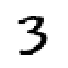

In [ ]:
show_image(three_tensors[1]);

Для каждой позиции пикселя мы хотим вычислить среднее значение интенсивности этого пикселя по всем изображениям. Для этого мы сначала объединяем все изображения из этого списка в один трехмерный тензор. Наиболее распространенный способ описания такого тензора – это назвать его тензором *ранга 3*. Часто нам необходимо объединить отдельные тензоры в коллекции в один тензор. Как и следовало ожидать, в PyTorch есть функция под названием `stack`, которую мы можем использовать для этой цели.

Некоторые операции в PyTorch, такие как вычисление среднего значения, требуют от нас преобразования целочисленных типов в числа с плавающей точкой. Поскольку нам это понадобится позже, мы также преобразуем наш объединенный тензор в тип `float`. Преобразование типов в PyTorch настолько просто, как указание имени типа, к которому вы хотите преобразовать, и использование его как метода.

Как правило, когда изображения представлены числами с плавающей точкой, ожидается, что значения пикселей будут находиться в диапазоне от 0 до 1, поэтому мы также разделим значения на 255:


In [ ]:
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
stacked_threes.shape

torch.Size([6131, 28, 28])

Возможно, самым важным атрибутом тензора является его *форма*. Она указывает длину каждой оси. В данном случае мы видим, что у нас есть 6131 изображение, каждое размером 28x28 пикселей. В этой структуре тензора нет ничего, что бы явно указывало, что первая ось соответствует количеству изображений, вторая — высоте, а третья — ширине. Семантика тензора полностью зависит от нас и от того, как мы его создаем. С точки зрения PyTorch, это просто набор чисел, хранящихся в памяти.

*Длина* формы тензора является его рангом:


In [ ]:
len(stacked_threes.shape)

3

Очень важно запомнить и практиковать использование этих терминов, связанных с тензорами: "_ранг_" (rank) – это число осей или измерений в тензоре; "_форма_" (shape) – это размер каждой оси тензора.

> Внимание: термин "измерение" иногда используется в двух разных значениях. Представьте, что мы живем в "трехмерном пространстве", где физическое положение можно описать трехмерным вектором `v`. Но, согласно PyTorch, атрибут `v.ndim` (который, безусловно, выглядит как "число измерений" вектора `v`) равен одному, а не трем! Почему? Потому что `v` – это вектор, который является тензором ранга один, то есть он имеет только одну ось (даже если эта ось имеет длину три). Другими словами, иногда "измерение" используется для обозначения размера оси ("пространство трехмерное"), а иногда – для обозначения ранга, или числа осей ("матрица имеет два измерения"). Когда возникает путаница, мне помогает перефразировать все утверждения, используя термины "ранг", "ось" и "длина", которые являются однозначными.

Мы также можем получить ранг тензора напрямую, используя функцию `ndim`:


In [ ]:
stacked_threes.ndim

3

Наконец, мы можем вычислить, как выглядит "идеальное" изображение. Мы рассчитываем среднее значение всех тензоров изображений, вычисляя среднее значение по измерению 0 нашего объединенного тензора ранга 3. Это измерение, которое определяет все изображения.

Другими словами, для каждой позиции пикселя будет вычислено среднее значение этого пикселя по всем изображениям. Результатом будет одно значение для каждой позиции пикселя, или одно изображение. Вот оно:


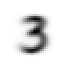

In [ ]:
mean3 = stacked_threes.mean(0)
show_image(mean3);

Согласно этим данным, это идеальное значение "3"! (Возможно, вам это не понравится, но это и есть оптимальное качество изображения для значения "3"). Вы можете видеть, насколько темным оно становится там, где все изображения согласны, что там должно быть темно, но оно становится размытым и нечетким там, где изображения расходятся во мнениях.

Теперь сделаем то же самое для цифры "7", но объединим все шаги сразу, чтобы сэкономить время:


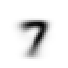

In [ ]:
mean7 = stacked_sevens.mean(0)
show_image(mean7);

Теперь давайте выберем произвольную цифру и измерим ее *расстояние* от наших "идеальных" образцов.

> Пауза: Остановитесь и подумайте! Как бы вы вычислили, насколько похожа конкретная цифра на каждый из наших "идеальных" образцов? Не забудьте оторваться от этой книги и записать несколько идей, прежде чем двигаться дальше! Исследования показывают, что запоминание и понимание значительно улучшаются, когда вы активно вовлечены в процесс обучения, решая задачи, экспериментируя и пробуя новые идеи самостоятельно.

Вот пример цифры:


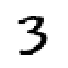

In [ ]:
a_3 = stacked_threes[1]
show_image(a_3);

Как мы можем определить расстояние от этого изображения до нашего идеального образца цифры? Мы не можем просто сложить разности между пикселями этого изображения и пикселями идеальной цифры. Некоторые разности будут положительными, а другие – отрицательными, и эти разности взаимно компенсируются, что приведет к ситуации, когда изображение, которое слишком темное в одних местах и слишком светлое в других, может быть показано как имеющее нулевую общую разницу с идеальным образцом. Это было бы вводит в заблуждение!

Чтобы избежать этого, существуют два основных способа, которыми специалисты по данным измеряют расстояние в данном контексте:

- Вычисляется среднее значение *абсолютной величины* разностей (абсолютная величина – это функция, которая заменяет отрицательные значения на положительные). Это называется *средней абсолютной разностью* или *L1-нормой*.
- Вычисляется среднее значение *квадрата* разностей (что делает все значения положительными), а затем извлекается *квадратный корень* (который отменяет возведение в квадрат). Это называется *среднеквадратичной ошибкой* (RMSE) или *L2-нормой*.

> Важно: Не переживайте, если вы забыли математику: В этой книге мы обычно предполагаем, что вы закончили обучение в средней школе и помните хотя бы часть математических знаний... Но все забывают что-то! Все зависит от того, какие темы вам приходилось изучать и практиковать в последнее время. Возможно, вы забыли, что такое *квадратный корень*, или как он работает. Ничего страшного! В любой момент, когда вы сталкиваетесь с математическим понятием, которое не полностью объяснено в этой книге, не просто переходите дальше; вместо этого остановитесь и посмотрите информацию об этом понятии. Убедитесь, что вы понимаете основную идею, как она работает и почему мы можем ее использовать. Одним из лучших мест для повторения и закрепления знаний является Khan Academy. Например, на Khan Academy есть отличное [введение в квадратные корни](https://www.khanacademy.org/math/algebra/x2f8bb11595b61c86:rational-exponents-radicals/x2f8bb11595b61c86:radicals/v/understanding-square-roots).

Давайте попробуем оба этих варианта:

In [ ]:
dist_3_abs = (a_3 - mean3).abs().mean()
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [ ]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

В обоих случаях расстояние между нашим значением "3" и "идеальным" значением "3" меньше, чем расстояние до "идеального" значения "7". Таким образом, наша простая модель даст правильный прогноз в этом случае.

PyTorch уже предоставляет обе эти функции в виде *функций потерь*. Вы можете найти их в модуле `torch.nn.functional`, который команда PyTorch рекомендует импортировать под именем `F` (и который по умолчанию доступен под этим именем в библиотеке fastai).

In [ ]:
F.l1_loss(a_3.float(),mean7), F.mse_loss(a_3,mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

Здесь `mse` обозначает *среднеквадратичную ошибку*, а `l1` – это стандартный математический термин, обозначающий *среднее абсолютное значение* (в математике это называется *нормой L1*).

Вот перевод:

> S: Интуитивно, разница между L1-нормой и среднеквадратичной ошибкой (MSE) заключается в том, что последняя будет более строго наказывать за большие ошибки, чем первая (и будет более снисходительной к небольшим ошибкам).

J: Когда я впервые столкнулся с этим термином "L1", я поискал его в интернете, чтобы понять, что он вообще означает. Я нашел в Google, что это _норма вектора_, использующая _абсолютное значение_, поэтому я поискал определение _нормы вектора_ и начал читать: _Пусть V – векторное пространство над полем F, состоящим из действительных или комплексных чисел. Норма на V – это функция p: V → [0, +∞), принимающая неотрицательные значения, которая обладает следующими свойствами: для всех a ∈ F и всех u, v ∈ V, p(u + v) ≤ p(u) + p(v)..._ Затем я перестал читать. "Фух, я никогда не пойму математику!", – подумал я, в тысячный раз. С тех пор я узнал, что каждый раз, когда в практике возникают эти сложные математические термины, оказывается, что я могу заменить их небольшим фрагментом кода! Например, _L1-функция потерь_ просто равна `(a-b).abs().mean()`, где `a` и `b` – тензоры. Я думаю, что люди, занимающиеся математикой, просто мыслят иначе, чем я... Я постараюсь в этой книге, чтобы каждый раз, когда появляется какой-либо сложный математический термин, я предоставлял вам небольшой фрагмент кода, который ему соответствует, и объяснял простым языком, что происходит.

Мы только что выполнили различные математические операции над тензорами PyTorch. Если вы ранее занимались числовым программированием с использованием NumPy, вы, возможно, заметите, что эти операции похожи на операции с массивами NumPy. Давайте рассмотрим эти две очень важные структуры данных.

### Массивы NumPy и тензоры PyTorch.

[NumPy](https://numpy.org/) – это наиболее широко используемая библиотека для научных и числовых вычислений на языке Python. Она предоставляет функциональность и API, очень похожие на те, что предлагает PyTorch; однако, она не поддерживает использование графического процессора (GPU) и не позволяет вычислять градиенты, что критически важно для глубокого обучения. Поэтому, в этой книге мы будем, по возможности, использовать тензоры PyTorch вместо массивов NumPy.

(Обратите внимание, что библиотека fastai добавляет некоторые функции в NumPy и PyTorch, чтобы сделать их более похожими друг на друга. Если какой-либо код в этой книге не работает на вашем компьютере, возможно, вы забыли добавить в начало вашего блокнота строку: `from fastai.vision.all import *`.)

Но что такое массивы и тензоры, и почему вам стоит об этом знать?


Python работает медленнее, чем многие другие языки. Все, что работает быстро в Python, NumPy или PyTorch, скорее всего, является оберткой для скомпилированного объекта, написанного (и оптимизированного) на другом языке, а именно на C. Фактически, **массивы NumPy и тензоры PyTorch могут выполнять вычисления во много тысяч раз быстрее, чем при использовании чистого Python.**

Массив NumPy – это многомерная таблица данных, в которой все элементы имеют один и тот же тип. Поскольку это может быть любой тип, это могут быть даже массивы массивов, причем массивы, находящиеся на самом внутреннем уровне, могут иметь разную размерность – это называется "неровным массивом". Под "многомерной таблицей" мы подразумеваем, например, список (одномерность), таблицу или матрицу (двумерность), "таблицу таблиц" или "куб" (трехмерность) и так далее. Если все элементы имеют простой тип, такой как целое число или число с плавающей точкой, то NumPy сохраняет их в памяти как компактную структуру данных на C. Именно здесь NumPy проявляет свои сильные стороны. NumPy имеет широкий спектр операторов и методов, которые могут выполнять вычисления на этих компактных структурах со скоростью, сопоставимой с оптимизированным C, поскольку они написаны на оптимизированном C.

Тензор PyTorch почти идентичен массиву NumPy, но имеет дополнительное ограничение, которое открывает дополнительные возможности. Он аналогичен массиву в том, что это также многомерная таблица данных, в которой все элементы имеют один и тот же тип. Однако ограничение заключается в том, что тензор не может использовать произвольный тип – он должен использовать один базовый числовой тип для всех компонентов. Например, тензор PyTorch не может быть неровным. Он всегда представляет собой многомерную прямоугольную структуру с регулярной формой.

Подавляющее большинство методов и операторов, поддерживаемых NumPy для этих структур, также поддерживаются PyTorch, но тензоры PyTorch имеют дополнительные возможности. Одна из основных возможностей заключается в том, что эти структуры могут располагаться в памяти графического процессора (GPU), в этом случае их вычисления будут оптимизированы для GPU и могут выполняться намного быстрее (при наличии большого объема данных для обработки). Кроме того, PyTorch может автоматически вычислять производные этих операций, включая комбинации операций. Как вы увидите, практическое применение глубокого обучения было бы невозможно без этой возможности.

> С: Если вы не знаете, что такое C, не беспокойтесь, вам это не понадобится. Вкратце, это язык низкого уровня (низкий уровень означает большую схожесть с языком, который компьютеры используют внутри), который работает намного быстрее, чем Python. Чтобы воспользоваться его скоростью при программировании на Python, старайтесь максимально избегать написания циклов и заменяйте их командами, которые работают непосредственно с массивами или тензорами.

Возможно, самым важным новым навыком программирования для разработчика на Python является умение эффективно использовать API массивов/тензоров. Мы покажем вам еще много приемов позже в этой книге, но вот краткое изложение ключевых вещей, которые вам нужно знать на данный момент.


Для создания массива или тензора, передайте список (или список списков, или список списков списков и т.д.) функциям `array()` или `tensor()`:


In [ ]:
data = [[1,2,3],[4,5,6]]
arr = array (data)
tns = tensor(data)

In [ ]:
arr  # numpy

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
tns  # pytorch

tensor([[1, 2, 3],
        [4, 5, 6]])

Все последующие операции демонстрируются на тензорах, но синтаксис и результаты для массивов NumPy идентичны.

Вы можете выбрать строку (обратите внимание, что, как и списки в Python, тензоры имеют нулевую индексацию, поэтому 1 означает вторую строку/столбец):


In [ ]:
tns[1]

tensor([4, 5, 6])

или столбец, используя символ `:` для указания *всех элементов первой оси* (мы иногда называем размеры тензоров/массивов "осями"):

In [ ]:
tns[:,1]

tensor([2, 5])

Вы можете комбинировать эти возможности с синтаксисом срезов Python (`[start:end]`, где `end` не включается), чтобы выбрать часть строки или столбца:


In [ ]:
tns[1,1:3]

tensor([5, 6])

И вы можете использовать стандартные операторы, такие как `+`, `-`, `*`, `/`:


In [ ]:
tns+1

tensor([[2, 3, 4],
        [5, 6, 7]])

Тензоры имеют тип:


In [ ]:
tns.type()

'torch.LongTensor'

И автоматически будет изменять тип данных по мере необходимости, например, с `int` на `float`:


In [ ]:
tns*1.5

tensor([[1.5000, 3.0000, 4.5000],
        [6.0000, 7.5000, 9.0000]])

Итак, насколько хороша наша базовая модель? Чтобы это оценить, нам необходимо определить метрику.

## Вычисление метрик с использованием широковещания.


Вспомните, что метрика – это число, которое рассчитывается на основе прогнозов нашей модели и правильных меток в нашем наборе данных, чтобы показать, насколько хорошо работает наша модель. Например, мы можем использовать любую из функций, которые мы видели в предыдущем разделе, среднюю квадратичную ошибку или среднюю абсолютную ошибку, и взять их среднее значение для всего набора данных. Однако ни одно из этих чисел не является легко понятным для большинства людей; на практике мы обычно используем *точность* в качестве метрики для моделей классификации.

Как мы уже обсуждали, мы хотим рассчитать нашу метрику на *валидационном наборе*. Это необходимо, чтобы избежать случайной переподгонки – то есть, чтобы не обучить модель, которая хорошо работает только на наших обучающих данных. Это не является большой проблемой для модели сравнения пикселей, которую мы используем здесь в качестве первого шага, поскольку у нее нет обучаемых компонентов, но мы все равно будем использовать валидационный набор, чтобы следовать стандартным практикам и быть готовыми к нашей второй попытке позже.

Чтобы получить валидационный набор, нам нужно удалить часть данных из обучающего набора, чтобы модель вообще не видела их. Как оказалось, создатели набора данных MNIST уже сделали это за нас. Вы помните, что была отдельная директория под названием *valid*? Вот для чего она предназначена!

Итак, для начала давайте создадим тензоры для наших цифр 3 и 7 из этой директории. Эти тензоры мы будем использовать для расчета метрики, которая измеряет качество нашей модели, используемой в качестве первого шага, и которая измеряет расстояние от идеального изображения:


In [ ]:
valid_3_tens = torch.stack([tensor(Image.open(o)) 
                            for o in (path/'valid'/'3').ls()])
valid_3_tens = valid_3_tens.float()/255
valid_7_tens = torch.stack([tensor(Image.open(o)) 
                            for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255
valid_3_tens.shape,valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

Полезно привыкнуть к тому, чтобы проверять размеры тензоров в процессе работы. Здесь мы видим два тензора: один представляет собой набор данных для валидации, содержащий 1010 изображений размером 28x28, предназначенных для классификации цифры "3", а другой – набор данных для валидации, содержащий 1028 изображений размером 28x28, предназначенных для классификации цифры "7".

В конечном итоге, мы хотим создать функцию `is_3`, которая будет определять, является ли произвольное изображение цифрой "3" или "7". Она будет делать это, определяя, к какому из наших двух "идеальных образцов" цифры это произвольное изображение ближе. Для этого нам нужно определить понятие расстояния, то есть функцию, которая вычисляет расстояние между двумя изображениями.

Мы можем написать простую функцию, которая вычисляет среднюю абсолютную ошибку, используя выражение, очень похожее на то, что мы написали в предыдущем разделе:


In [ ]:
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))
mnist_distance(a_3, mean3)

tensor(0.1114)

Это то же значение, которое мы ранее вычислили для расстояния между этими двумя изображениями, идеальным образцом "3" (`mean3`) и произвольным образцом "3" (`a_3`), которые оба являются тензорами, представляющими одно изображение, и имеют форму `[28, 28]`.

Однако, чтобы рассчитать метрику общей точности, нам потребуется вычислить расстояние до идеального образца "3" для *каждого* изображения в наборе для проверки. Как мы можем выполнить это вычисление? Мы могли бы написать цикл, перебирающий все тензоры, представляющие отдельные изображения, которые объединены в тензор набора для проверки `valid_3_tens`, имеющий форму `[1010, 28, 28]`, что соответствует 1010 изображениям. Но есть более эффективный способ.

Очень интересное происходит, когда мы используем ту же самую функцию вычисления расстояния, предназначенную для сравнения двух отдельных изображений, но передаем ей в качестве аргумента `valid_3_tens`, тензор, представляющий набор для проверки, состоящий из образцов "3":


In [ ]:
valid_3_dist = mnist_distance(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1050, 0.1526, 0.1186,  ..., 0.1122, 0.1170, 0.1086]),
 torch.Size([1010]))

Вместо того, чтобы жаловаться на несовпадение форм, функция возвращала расстояние для каждого изображения в виде вектора (то есть, тензора ранга 1) длиной 1010 (количество цифр "3" в нашем наборе данных для проверки). Как это произошло?

Еще раз внимательно посмотрите на нашу функцию `mnist_distance`, и вы увидите, что там есть операция вычитания `(a-b)`. "Магический трюк" заключается в том, что PyTorch, при попытке выполнить простое вычитание между двумя тензорами разного ранга, использует *широковещание (broadcasting)*. То есть, он автоматически расширяет тензор с меньшим рангом, чтобы он имел тот же размер, что и тензор с большим рангом. Широковещание – это важная функция, которая значительно упрощает написание кода для работы с тензорами.

После того, как выполняется широковещание, и два аргумента тензора имеют одинаковый ранг, PyTorch применяет свою обычную логику для двух тензоров одного ранга: он выполняет операцию над каждым соответствующим элементом этих двух тензоров и возвращает результирующий тензор. Например:


In [ ]:
tensor([1,2,3]) + tensor(1)

tensor([2, 3, 4])

В данном случае, PyTorch рассматривает `mean3`, тензор ранга 2, представляющий собой одно изображение, как будто это 1010 копий этого же изображения, и затем вычитает каждую из этих копий из каждого элемента, равного 3, в нашем наборе данных для проверки. Какую форму, по вашему мнению, должен иметь этот тензор? Попробуйте самостоятельно разобраться, прежде чем посмотреть на ответ ниже:

In [ ]:
(valid_3_tens-mean3).shape

torch.Size([1010, 28, 28])

Мы вычисляем разницу между нашими "идеальными 3" и каждым из 1010 образцов "3" в наборе для проверки, для каждого изображения размером 28x28, в результате чего получается массив формы `[1010, 28, 28]`.

Существует несколько важных моментов, касающихся реализации механизма широковещания (broadcasting), которые делают его ценным не только с точки зрения выразительности, но и с точки зрения производительности:

- PyTorch *фактически* не копирует `mean3` 1010 раз. Он *имитирует*, что это тензор такой формы, но при этом не выделяет дополнительную память.
- Все вычисления выполняются на C (или, если используется графический процессор, на CUDA, что является аналогом C для графического процессора), что в десятки тысяч раз быстрее, чем чистый Python (а на графическом процессоре – до миллионов раз быстрее!).

Это справедливо для всех операций и функций, использующих механизм широковещания и выполняемых поэлементно в PyTorch. *Это самый важный прием, который вам необходимо знать для написания эффективного кода на PyTorch.*

Далее, в функции `mnist_distance` мы видим `abs`. Теперь вы можете предположить, что делает эта функция, когда применяется к тензору. Она применяет метод к каждому отдельному элементу тензора и возвращает тензор с результатами (то есть, она применяет метод "поэлементно"). Таким образом, в данном случае мы получим 1010 матриц, содержащих абсолютные значения.

Наконец, наша функция вызывает `mean((-1,-2))`. Кортеж `(-1,-2)` представляет собой диапазон осей. В Python `-1` относится к последнему элементу, а `-2` – ко второму с конца. Следовательно, в данном случае это указывает PyTorch, что мы хотим вычислить среднее значение для элементов, индексированных последними двумя осями тензора. Последние две оси – это горизонтальные и вертикальные размеры изображения. После вычисления среднего значения по последним двум осям, у нас остается только первая ось тензора, которая индексирует наши изображения, поэтому конечный размер массива – `(1010)`. Другими словами, для каждого изображения мы вычисляем среднюю интенсивность всех пикселей в этом изображении.

Мы узнаем гораздо больше о механизме широковещания на протяжении всей этой книги, особенно в разделе <<chapter_foundations>>, и будем регулярно практиковаться в его использовании.

Мы можем использовать функцию `mnist_distance` для определения, является ли изображение "3" или нет, используя следующую логику: если расстояние между рассматриваемой цифрой и "идеальной 3" меньше, чем расстояние до "идеальной 7", то это "3". Эта функция автоматически использует механизм широковещания и применяется поэлементно, как и все функции и операторы PyTorch:


In [ ]:
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x,mean7)

Давайте протестируем это на нашем примере:


In [ ]:
is_3(a_3), is_3(a_3).float()

(tensor(True), tensor(1.))

Обратите внимание, что при преобразовании булевого значения в число с плавающей точкой, мы получаем `1.0` для `True` и `0.0` для `False`. Благодаря механизму вещания (broadcasting), мы также можем проверить это на полном наборе данных для валидации, состоящем из 3-х элементов:


In [ ]:
is_3(valid_3_tens)

tensor([True, True, True,  ..., True, True, True])

Теперь мы можем вычислить точность для каждой группы чисел "3" и "7", взяв среднее значение соответствующей функции для всех чисел "3" и ее обратное значение для всех чисел "7".

In [ ]:
accuracy_3s =      is_3(valid_3_tens).float() .mean()
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()

accuracy_3s,accuracy_7s,(accuracy_3s+accuracy_7s)/2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

Это выглядит как довольно неплохое начало! Мы достигаем точности более 90% как для цифр "3", так и для "7", и мы уже знаем, как удобно определять метрики, используя механизм широковещания.

Но будем честны: цифры "3" и "7" выглядят очень по-разному. И на данный момент мы классифицируем только 2 из 10 возможных цифр. Значит, нам нужно добиться лучших результатов!

Чтобы улучшить результаты, возможно, пора попробовать систему, которая действительно обучается, то есть, которая может автоматически адаптироваться для повышения своей эффективности. Другими словами, пора поговорить о процессе обучения и о стохастическом градиентном спуске (SGD).

## Стохастический градиентный спуск (SGD)


Вам помнится, как Артур Сэмюэл описывал машинное обучение, цитату из которого мы приводили во введении к главе?

> : Предположим, мы создаем систему автоматического тестирования эффективности текущей конфигурации параметров с точки зрения фактической производительности и предоставляем механизм для изменения этой конфигурации, чтобы максимизировать производительность. Нам не нужно вдаваться в детали такой процедуры, чтобы увидеть, что ее можно сделать полностью автоматической, и понять, что машина, запрограммированная таким образом, будет "учиться" на своем опыте.

Как мы обсуждали, это ключевой момент, позволяющий нам создать модель, которая может постоянно улучшаться и, следовательно, учиться. Однако наш подход, основанный на сравнении пикселей, на самом деле этого не делает. У нас нет никакой системы назначения весов или способа улучшения, основанного на тестировании эффективности такой системы. Другими словами, мы не можем по-настоящему улучшить наш подход, основанный на сравнении пикселей, путем изменения набора параметров. Чтобы воспользоваться преимуществами глубокого обучения, нам сначала нужно представить нашу задачу так, как это описал Артур Сэмюэл.

Вместо того, чтобы пытаться найти сходство между изображением и "идеальным изображением", мы можем рассмотреть каждый отдельный пиксель и определить набор весов для каждого из них, так чтобы самые высокие веса соответствовали пикселям, которые с наибольшей вероятностью будут черными для определенной категории. Например, пиксели в правом нижнем углу изображения маловероятно будут активны для цифры "7", поэтому они должны иметь низкий вес для этой цифры, но, скорее всего, будут активны для цифры "8", поэтому они должны иметь высокий вес для этой цифры. Это можно представить в виде функции и набора значений весов для каждой возможной категории, например, вероятности того, что это цифра "8":

```
def pr_eight(x,w): return (x*w).sum()
```

Здесь мы предполагаем, что `x` – это изображение, представленное в виде вектора, то есть все строки изображения объединены в одну длинную последовательность. Мы также предполагаем, что веса – это вектор `w`. Если у нас есть такая функция, нам просто нужно найти способ обновить веса, чтобы сделать их немного лучше. Используя такой подход, мы можем повторять этот шаг несколько раз, постепенно улучшая веса, пока они не достигнут оптимального значения.

Мы хотим найти конкретные значения для вектора `w`, которые приведут к тому, что результат нашей функции будет высоким для изображений, которые на самом деле являются цифрой 8, и низким для изображений, которые не являются цифрой 8. Поиск наилучшего вектора `w` – это способ найти наилучшую функцию для распознавания цифры 8. (Поскольку мы пока не используем глубокую нейронную сеть, мы ограничены возможностями нашей функции, но мы устраним это ограничение позже в этой главе).

Чтобы быть более конкретными, вот шаги, которые нам понадобятся, чтобы преобразовать эту функцию в классификатор машинного обучения:

1. *Инициализируйте* веса.
2. Для каждого изображения используйте эти веса для *предсказания*, является ли оно цифрой 3 или 7.
3. На основе этих предсказаний рассчитайте, насколько хорошо работает модель (ее *потерю*).
4. Рассчитайте *градиент*, который показывает для каждого веса, как изменение этого веса повлияет на потерю.
5. *Измените* все веса на основе этого расчета.
6. Вернитесь к шагу 2 и *повторите* процесс.
7. Повторяйте, пока не решите *остановить* процесс обучения (например, потому что модель достаточно хороша или вы не хотите ждать больше).

Эти семь шагов, иллюстрированные в разделе <<gradient_descent>>, являются ключевыми для обучения всех моделей глубокого обучения. Тот факт, что глубокое обучение полностью основано на этих шагах, является чрезвычайно удивительным и противоречивым. Удивительно, что этот процесс может решать такие сложные задачи. Но, как вы увидите, это действительно так!

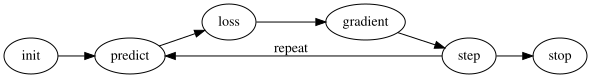

In [ ]:
#id gradient_descent
#caption The gradient descent process
#alt Graph showing the steps for Gradient Descent
gv('''
init->predict->loss->gradient->step->stop
step->predict[label=repeat]
''')

Существует множество различных способов выполнения каждого из этих семи шагов, и мы будем изучать их на протяжении всей этой книги. Эти детали имеют большое значение для специалистов в области глубокого обучения, но, как оказалось, общий подход к каждому из них обычно основан на некоторых базовых принципах. Вот несколько рекомендаций:

- Инициализация: Мы инициализируем параметры случайными значениями. Это может показаться удивительным. Конечно, у нас есть и другие варианты, например, инициализировать их значениями, соответствующими частоте активации пикселя для данной категории, но, поскольку у нас уже есть механизм для улучшения этих весов, оказывается, что простое использование случайных весов работает вполне хорошо.
- Функция потерь: Это то, что Сэмюэл имел в виду, когда говорил о *проверке эффективности текущего присваивания весов с точки зрения фактической производительности*. Нам нужна функция, которая будет возвращать число, которое будет небольшим, если производительность модели хорошая (стандартный подход заключается в том, чтобы рассматривать небольшое значение функции потерь как хорошее, а большое – как плохое, хотя это всего лишь соглашение).
- Шаг: Простой способ определить, следует ли увеличить или уменьшить вес, – это просто попробовать: увеличить вес на небольшую величину и посмотреть, увеличится или уменьшится функция потерь. Найдя правильное направление, можно затем немного увеличить или уменьшить это значение, пока не будет найдено значение, которое работает хорошо. Однако это медленно! Как мы увидим, магия математического анализа позволяет нам напрямую определить, в каком направлении и примерно на сколько нужно изменить каждый вес, не прибегая к необходимости пробовать все эти небольшие изменения. Это достигается путем вычисления *градиентов*. Это всего лишь оптимизация производительности, мы получим точно такие же результаты, используя более медленный ручной процесс.
- Остановка: Как только мы решили, сколько эпох обучать модель (некоторые предложения по этому поводу были приведены в предыдущем списке), мы применяем это решение. Именно здесь это решение и реализуется. Для нашего классификатора цифр мы бы продолжали обучение до тех пор, пока точность модели не начала ухудшаться, или пока у нас не закончилось время.

Прежде чем применять эти шаги к нашей задаче классификации изображений, давайте рассмотрим, как они выглядят на более простом примере. Сначала мы определим очень простую функцию – квадратичную. Представим, что это наша функция потерь, а `x` – это параметр функции, определяющий ее вес:


In [ ]:
def f(x): return x**2

Вот график этой функции:

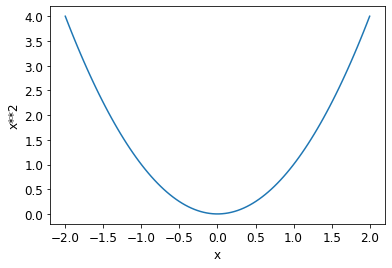

In [ ]:
plot_function(f, 'x', 'x**2')

Последовательность шагов, которую мы описали ранее, начинается с выбора случайного значения для определенного параметра, после чего вычисляется значение функции потерь:


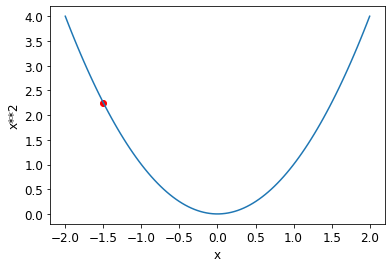

In [ ]:
plot_function(f, 'x', 'x**2')
plt.scatter(-1.5, f(-1.5), color='red');

Теперь давайте посмотрим, что произойдет, если мы немного увеличим или уменьшим наш параметр — это и есть *корректировка*. Это просто наклон кривой в определенной точке:


```markdown
<img alt="График квадратичной функции с указанием наклона в одной точке" width="400" src="images/grad_illustration.svg"/>
```

Мы можем немного изменить наш вес в направлении наклона, повторно рассчитать наши потери и корректировки, и повторить этот процесс несколько раз. В конечном итоге, мы достигнем самой низкой точки на нашей кривой:


```markdown
<img alt="Иллюстрация метода градиентного спуска" width="400" src="images/chapter2_perfect.svg"/>
```

Эта базовая идея восходит к Исааку Ньютону, который отметил, что мы можем оптимизировать любые функции таким образом. Независимо от того, насколько сложными становятся наши функции, этот основной подход, основанный на градиентном спуске, не претерпит существенных изменений. Единственные незначительные изменения, которые мы увидим позже в этой книге, касаются удобных способов, с помощью которых мы можем ускорить этот процесс, находя более оптимальные шаги.

### Расчет градиентов


Один ключевой момент – это этап, на котором мы вычисляем градиенты. Как мы уже упоминали, мы используем математический анализ для оптимизации производительности; это позволяет нам быстрее определить, увеличится или уменьшится наша функция потерь, если мы изменим параметры модели. Другими словами, градиенты показывают, насколько нужно изменить каждый вес, чтобы улучшить работу модели.

Возможно, вы помните из уроков математического анализа в школе, что *производная* функции показывает, насколько изменится результат при изменении ее параметров. Если вы забыли, не беспокойтесь, многие из нас забывают математический анализ, когда заканчивают школу! Но вам необходимо иметь некоторое интуитивное понимание того, что такое производная, прежде чем двигаться дальше. Если у вас нет четкого представления об этом, перейдите на Khan Academy и пройдите [уроки по основам производных](https://www.khanacademy.org/math/differential-calculus/dc-diff-intro). Вам не нужно уметь вычислять производные самостоятельно, достаточно понимать, что такое производная.

Главное, что нужно знать о производной, это то, что для любой функции, например, для квадратичной функции, которую мы видели в предыдущем разделе, мы можем вычислить ее производную. Производная – это другая функция. Она показывает изменение, а не значение. Например, производная квадратичной функции в точке 3 показывает, насколько быстро функция меняется в этой точке. Более конкретно, вы, возможно, помните, что градиент определяется как *изменение значения функции, деленное на изменение значения параметра*. Когда мы знаем, как изменится наша функция, мы знаем, что нужно сделать, чтобы уменьшить ее значение. Это ключевой принцип машинного обучения: иметь возможность изменять параметры функции, чтобы уменьшить ее значение. Математический анализ предоставляет нам вычислительный "обходной путь" – производную, которая позволяет нам напрямую вычислять градиенты наших функций.

Важно понимать, что наша функция имеет множество параметров, которые необходимо корректировать. Поэтому, когда мы вычисляем производную, мы не получаем одно число, а множество чисел – градиент для каждого параметра. Однако, здесь нет ничего математически сложного: вы можете вычислить производную по одному параметру, рассматривая все остальные как константы, а затем повторить этот процесс для каждого параметра. Именно так вычисляются все градиенты для каждого параметра.

Мы только что упомянули, что вам не придется самостоятельно вычислять градиенты. Как это возможно? Удивительно, но PyTorch способен автоматически вычислять производную практически любой функции! Более того, он делает это очень быстро. В большинстве случаев, это будет не менее быстро, чем любая функция производной, которую вы можете создать вручную. Давайте рассмотрим пример.

Сначала выберем значение тензора, для которого мы хотим вычислить градиенты:


In [ ]:
xt = tensor(3.).requires_grad_()

Обратите внимание на специальный метод `requires_grad_`? Это своего рода "магическое заклинание", с помощью которого мы сообщаем PyTorch, что хотим вычислить градиенты для этой переменной при данном значении. По сути, это метка, которая позволяет PyTorch запомнить, как вычислять градиенты для этой переменной и для других операций, выполняемых над ней, которые вы запросите.

> a: Этот API может показаться вам странным, если вы пришли из математики или физики. В этих областях "градиент" функции – это просто другая функция (то есть, ее производная), поэтому вы можете ожидать, что API, связанные с градиентами, вернут вам новую функцию. Но в глубоком обучении "градиенты" обычно означают _значение_ производной функции при определенном аргументе. API PyTorch также делает акцент на аргументе, а не на самой функции, для которой вычисляются градиенты. Это может показаться непривычным на первый взгляд, но это просто другой взгляд на вещи.

Теперь мы вычисляем нашу функцию с этим значением. Обратите внимание, что PyTorch выводит не только вычисленное значение, но и сообщение о том, что у него есть функция для вычисления градиентов, которую он будет использовать, когда это потребуется:


In [ ]:
yt = f(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

В заключение, мы указываем PyTorch, чтобы он вычислил для нас градиенты:


In [ ]:
yt.backward()

Здесь термин "обратный" относится к *обратному распространению ошибки* (backpropagation), которое является процессом расчета производной для каждого слоя. Мы увидим, как это делается конкретно, в главе <<chapter_foundations>>, когда мы будем рассчитывать градиенты глубокой нейронной сети с нуля. Это называется "обратным проходом" сети, в отличие от "прямого прохода", где вычисляются активации. Жизнь, вероятно, была бы проще, если бы "обратный проход" просто назывался "calculate_grad", но специалисты в области глубокого обучения очень любят использовать специальную терминологию везде, где это возможно!

Теперь мы можем посмотреть значения градиентов, проверив атрибут `grad` нашего тензора:


In [ ]:
xt.grad

tensor(6.)

Если вы помните правила дифференциального исчисления, которые изучали в школе, то производная от `x**2` равна `2*x`. У нас `x=3`, следовательно, градиент должен быть `2*3=6`, что и было рассчитано PyTorch!

Теперь мы повторим предыдущие шаги, но с использованием векторного аргумента для нашей функции:


In [ ]:
xt = tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

И мы добавим параметр `sum` в нашу функцию, чтобы она могла принимать вектор (то есть тензор ранга 1) и возвращать скаляр (то есть тензор ранга 0):

In [ ]:
def f(x): return (x**2).sum()

yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

Наши градиенты равны `2*xt`, как и следовало ожидать!

In [ ]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])

Градиенты показывают нам только наклон нашей функции, они не указывают точно, насколько нужно изменить параметры. Однако они дают нам представление о том, насколько нужно изменить параметры: если наклон очень большой, это может говорить о том, что нам нужно внести больше корректировок, а если наклон очень маленький, это может указывать на то, что мы близки к оптимальному значению.

### Регулировка скорости обучения


Определение того, как изменять наши параметры на основе значений градиентов, является важной частью процесса глубокого обучения. Практически все подходы начинаются с базовой идеи умножения градиента на небольшое число, называемое *скоростью обучения* (LR). Скорость обучения часто является числом в диапазоне от 0,001 до 0,1, хотя это может быть и другое значение. Часто люди выбирают скорость обучения, просто попробовав несколько вариантов и определив, какой из них дает наилучшую модель после обучения (мы покажем вам более продвинутый подход позже в этой книге, который называется *детектор скорости обучения*). После выбора скорости обучения вы можете корректировать свои параметры, используя эту простую функцию:

```
w -= gradient(w) * lr
```

Это называется *шагом* в изменении параметров, с использованием *оптимизационного шага*. Обратите внимание на то, как мы *вычитаем* `gradient * lr` из параметра для его обновления. Это позволяет нам корректировать параметр в направлении наклона, увеличивая его, когда наклон отрицательный, и уменьшая его, когда наклон положительный. Мы хотим корректировать наши параметры в направлении наклона, потому что наша цель в глубоком обучении – *минимизировать* потерю.

Если вы выберете слишком низкую скорость обучения, это может потребовать большого количества итераций. <<descent_small>> иллюстрирует это.

```markdown
<img alt="Иллюстрация градиентного спуска с слишком низкой скоростью обучения" width="400" caption="Градиентный спуск при низкой скорости обучения" src="images/chapter2_small.svg" id="descent_small"/>
```

Однако выбор слишком высокого значения скорости обучения может быть еще хуже – это может привести к тому, что ошибка *увеличится*, как мы видим в разделе <<descent_div>>!

```markdown
<img alt="Иллюстрация градиентного спуска с слишком высоким значением скорости обучения" width="400" caption="Градиентный спуск при высоком значении скорости обучения" src="images/chapter2_div.svg" id="descent_div"/>
```

Если скорость обучения слишком высока, алгоритм может "колебаться" вместо того, чтобы действительно расходиться; рисунок <<descent_bouncy>> показывает, что это приводит к тому, что для успешного обучения требуется совершить множество шагов.

<img alt="Иллюстрация градиентного спуска с переменной скоростью обучения" width="400" caption="Градиентный спуск с переменной скоростью обучения" src="images/chapter2_bouncy.svg" id="descent_bouncy"/>

Теперь давайте применим все это на конкретном примере, охватывающем все этапы.

### Пример использования стохастического градиентного спуска (SGD) от начала до конца.

Мы уже видели, как использовать градиенты для поиска минимума. Теперь пришло время рассмотреть пример использования стохастического градиентного спуска (SGD) и увидеть, как поиск минимума может быть использован для обучения модели, чтобы она лучше соответствовала данным.

Начнем с простой, искусственной модели. Представьте, что вы измеряете скорость вагонетки американских горок, когда она поднимается на вершину холма. Она начинает двигаться быстро, а затем замедляется, поднимаясь в гору; она движется медленнее всего на вершине, а затем снова ускоряется, спускаясь вниз. Вы хотите создать модель, описывающую, как скорость меняется со временем. Если бы вы измеряли скорость вручную каждую секунду в течение 20 секунд, это могло бы выглядеть примерно так:


In [ ]:
time = torch.arange(0,20).float(); time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

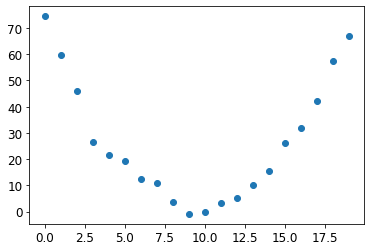

In [ ]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1
plt.scatter(time,speed);

Мы добавили немного случайного шума, поскольку ручные измерения не отличаются высокой точностью. Это означает, что ответить на вопрос: "Какова была скорость американских горок?" не так просто. Используя метод стохастического градиентного спуска (SGD), мы можем попытаться найти функцию, которая соответствует нашим наблюдениям. Мы не можем рассмотреть все возможные функции, поэтому давайте предположим, что она будет квадратичной, то есть иметь вид `a*(time**2)+(b*time)+c`.

Нам важно четко различать входные данные функции (время, в момент которого мы измеряем скорость аттракциона) и ее параметры (значения, определяющие, *какую именно* квадратичную функцию мы пытаемся найти). Поэтому давайте объединим параметры в один аргумент, чтобы отделить входные данные, `t`, и параметры, `params`, в сигнатуре функции:


In [ ]:
def f(t, params):
    a,b,c = params
    return a*(t**2) + (b*t) + c

Другими словами, мы сузили задачу поиска наилучшей функции, которая соответствует данным, до задачи поиска наилучшей *квадратичной* функции. Это значительно упрощает задачу, поскольку каждая квадратичная функция полностью определяется тремя параметрами: `a`, `b` и `c`. Таким образом, чтобы найти наилучшую квадратичную функцию, нам нужно найти наилучшие значения для `a`, `b` и `c`.

Если мы сможем решить эту задачу для трех параметров квадратичной функции, мы сможем применить тот же подход для других, более сложных функций с большим количеством параметров, например, для нейронной сети. Сначала мы найдем параметры для функции `f`, а затем мы вернемся и сделаем то же самое для набора данных MNIST, используя нейронную сеть.

Прежде всего, нам нужно определить, что мы подразумеваем под "наилучшей". Мы определяем это точно, выбирая *функцию потерь*, которая будет возвращать значение, основанное на прогнозе и целевом значении, где меньшие значения функции соответствуют "лучшим" прогнозам. Важно, чтобы функции потерь возвращали _меньшие_ значения, когда прогнозы более точны, поскольку процедура стохастического градиентного спуска (SGD), которую мы определили ранее, будет стремиться к _минимизации_ этих потерь. Для непрерывных данных часто используется *среднеквадратичная ошибка*:


In [ ]:
def mse(preds, targets): return ((preds-targets)**2).mean()

Теперь давайте рассмотрим наш процесс, состоящий из 7 этапов.

#### Шаг 1: Инициализация параметров.


Во-первых, мы инициализируем параметры случайными значениями и сообщаем PyTorch, что мы хотим отслеживать их градиенты, используя функцию `requires_grad_`:

In [ ]:
params = torch.randn(3).requires_grad_()

In [ ]:
#hide
orig_params = params.clone()

#### Шаг 2: Расчет прогнозов.

Далее мы рассчитываем прогнозы:


In [ ]:
preds = f(time, params)

Давайте создадим небольшую функцию, чтобы оценить, насколько точно наши прогнозы соответствуют целевым значениям, и посмотрим на результат:


In [ ]:
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

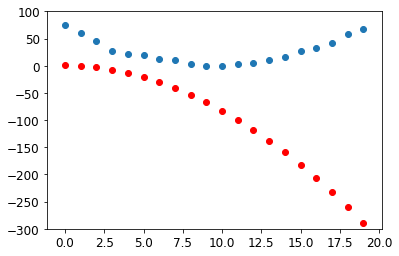

In [ ]:
show_preds(preds)

Судя по всему, результаты не очень точные. Наши случайные параметры указывают на то, что аттракцион, вероятно, начнет двигаться в обратном направлении, поскольку у нас наблюдаются отрицательные значения скорости!

#### Шаг 3: Расчет потерь.

Мы рассчитываем потерю следующим образом:


In [ ]:
loss = mse(preds, speed)
loss

tensor(25823.8086, grad_fn=<MeanBackward0>)

Наша цель сейчас – улучшить это. Для этого нам необходимо знать градиенты.

#### Шаг 4: Вычисление градиентов.

Следующий шаг – это вычисление градиентов. Иными словами, необходимо вычислить приблизительное значение того, как параметры должны измениться:

In [ ]:
loss.backward()
params.grad

tensor([-53195.8594,  -3419.7146,   -253.8908])

In [ ]:
params.grad * 1e-5

tensor([-0.5320, -0.0342, -0.0025])

Мы можем использовать эти градиенты для улучшения наших параметров. Нам необходимо выбрать скорость обучения (мы обсудим, как это делать на практике, в следующей главе; пока мы просто используем значение 1e-5, или 0.00001):

In [ ]:
params

tensor([-0.7658, -0.7506,  1.3525], requires_grad=True)

#### Шаг 5: Установите веса.


Теперь нам нужно обновить параметры, используя градиенты, которые мы только что вычислили:


In [ ]:
lr = 1e-5
params.data -= lr * params.grad.data
params.grad = None

Вот перевод:

> a: Понимание этой части требует знания недавней истории. Для вычисления градиентов мы вызываем функцию `backward` для объекта `loss`. Но этот объект `loss` сам был рассчитан функцией `mse`, которая, в свою очередь, принимала `preds` в качестве входных данных. `preds` были вычислены с использованием функции `f`, которая принимала `params` в качестве входных данных. `params` – это объект, для которого мы изначально вызвали функцию `requires_grad_`, что и является первоначальным вызовом, который теперь позволяет нам вызвать `backward` для объекта `loss`. Эта цепочка вызовов функций представляет собой математическую композицию функций, что позволяет PyTorch использовать правило дифференцирования сложной функции для вычисления этих градиентов.

Давайте посмотрим, улучшились ли результаты:


In [ ]:
preds = f(time,params)
mse(preds, speed)

tensor(5435.5366, grad_fn=<MeanBackward0>)

А теперь давайте посмотрим на сюжет:

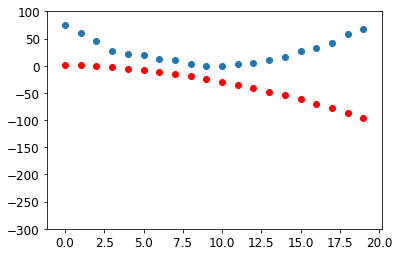

In [ ]:
show_preds(preds)

Нам нужно повторить это несколько раз, поэтому мы создадим функцию, которая будет выполнять один шаг:


In [ ]:
def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= lr * params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return preds

#### Шаг 6: Повторите процесс.


Теперь мы переходим к итеративному процессу. Благодаря повторению и внесению множества улучшений, мы надеемся достичь хорошего результата:


In [ ]:
for i in range(10): apply_step(params)

5435.53662109375
1577.4495849609375
847.3780517578125
709.22265625
683.0757446289062
678.12451171875
677.1839599609375
677.0025024414062
676.96435546875
676.9537353515625


In [ ]:
#hide
params = orig_params.detach().requires_grad_()

Потери уменьшаются, как мы и надеялись! Однако, анализ только этих значений потерь скрывает тот факт, что каждая итерация представляет собой попытку использования совершенно другой квадратичной функции, в процессе поиска наилучшей возможной квадратичной функции. Мы можем визуально увидеть этот процесс, если вместо вывода значения функции потерь, мы построим график функции на каждом шаге. Тогда мы сможем увидеть, как форма графика приближается к наилучшей возможной квадратичной функции для наших данных:

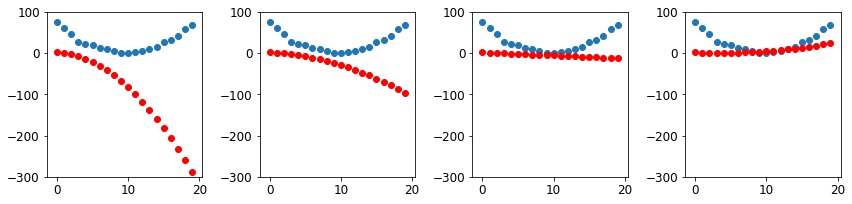

In [ ]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

#### Шаг 7: остановка.

Мы просто решили остановить процесс после 10 эпох, используя произвольный критерий. На практике мы бы следили за значениями потерь при обучении и валидации, а также за другими показателями, чтобы определить, когда следует остановить процесс, как мы уже обсуждали.

### Краткое описание метода градиентного спуска.


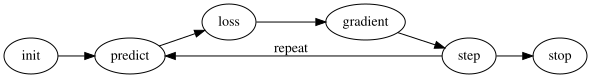

In [ ]:
#hide_input
#id gradient_descent
#caption The gradient descent process
#alt Graph showing the steps for Gradient Descent
gv('''
init->predict->loss->gradient->step->stop
step->predict[label=repeat]
''')

Вкратце, в начале обучения веса нашей модели могут быть случайными (обучение *с нуля*) или взяты из предварительно обученной модели (*трансферное обучение*). В первом случае, результат, который мы получим от наших входных данных, скорее всего, не будет соответствовать тому, что мы хотим. Даже во втором случае, предварительно обученная модель, вероятно, не будет очень хорошо справляться с конкретной задачей, которую мы решаем. Поэтому модели необходимо *научиться* определять более подходящие веса.

Мы начинаем с сравнения выходных данных, которые модель предоставляет, с нашими целевыми значениями (у нас есть размеченные данные, поэтому мы знаем, какой результат модель должна выдавать), используя *функцию потерь*, которая возвращает число, которое мы хотим сделать как можно меньше, улучшая наши веса. Для этого мы берем несколько элементов данных (например, изображения) из обучающего набора и подаем их в нашу модель. Мы сравниваем соответствующие целевые значения с помощью нашей функции потерь, и полученный результат показывает, насколько неточными были наши прогнозы. Затем мы немного изменяем веса, чтобы добиться небольшого улучшения.

Чтобы определить, как изменить веса для улучшения функции потерь, мы используем математический анализ для расчета *градиентов*. (На самом деле, мы позволяем PyTorch выполнить эту задачу за нас!) Давайте рассмотрим аналогию. Представьте, что вы заблудились в горах, а ваша машина припаркована в самой низкой точке. Чтобы найти дорогу обратно к ней, вы можете бродить в случайном направлении, но это, вероятно, не поможет. Поскольку вы знаете, что ваш автомобиль находится в самой низкой точке, вам лучше двигаться вниз по склону. Всегда делая шаг в направлении самого крутого спуска, вы в конечном итоге должны добраться до вашего места назначения. Мы используем величину градиента (то есть крутизну склона), чтобы определить, какой шаг нужно сделать; в частности, мы умножаем градиент на число, которое мы выбираем и называем *скоростью обучения*, чтобы определить размер шага. Затем мы *повторяем* этот процесс до тех пор, пока не достигнем самой низкой точки, которая будет нашим местом парковки, после чего мы можем *остановиться*.

Все, что мы только что рассмотрели, можно напрямую применить к набору данных MNIST, за исключением функции потерь. Теперь давайте посмотрим, как мы можем определить хорошую цель обучения.


## Функция потерь для набора данных MNIST.


У нас уже есть наши независимые переменные `x` – это сами изображения. Мы объединим все изображения в один тензор и также преобразуем их из списка матриц (тензор ранга 3) в список векторов (тензор ранга 2). Это можно сделать с помощью функции `view`, которая является методом PyTorch, изменяющим форму тензора без изменения его содержимого. Параметр `-1` является специальным параметром для `view` и означает "сделайте эту ось настолько большой, насколько это необходимо для размещения всех данных":

In [ ]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)

Нам нужна метка для каждого изображения. Мы будем использовать `1` для изображений с цифрой "3" и `0` для изображений с цифрой "7":


In [ ]:
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape,train_y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

В PyTorch класс `Dataset` должен возвращать кортеж `(x, y)` при обращении к нему по индексу. Python предоставляет функцию `zip`, которая, в сочетании с функцией `list`, обеспечивает простой способ реализации этой функциональности:


In [ ]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
x.shape,y

(torch.Size([784]), tensor([1]))

In [ ]:
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

Теперь нам нужен (изначально случайный) вес для каждого пикселя (это этап *инициализации* в нашем семиступенчатом процессе):


In [ ]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [ ]:
weights = init_params((28*28,1))

Функция `weights*pixels` будет недостаточно гибкой – она всегда будет равна 0, когда значения пикселей равны 0 (то есть, ее *смещение* равно 0). Возможно, вы помните из школьной математики, что формула для прямой – это `y = w*x + b`; нам по-прежнему нужен параметр `b`. Мы также инициализируем его случайным числом:


In [ ]:
bias = init_params(1)

В нейронных сетях, в уравнении `y = w * x + b`, `w` называется *весом* (weight), а `b` – *смещением* (bias). Вместе веса и смещение составляют *параметры*.

Вот перевод:

> терминология: Параметры: _Веса_ и _смещения_ модели. Веса – это `w` в уравнении `w*x+b`, а смещения – это `b` в этом уравнении.

Теперь мы можем вычислить прогноз для одного изображения:


In [ ]:
(train_x[0]*weights.T).sum() + bias

tensor([20.2336], grad_fn=<AddBackward0>)

Хотя мы могли бы использовать цикл `for` на Python для расчета прогноза для каждого изображения, это было бы очень медленно. Поскольку циклы Python не выполняются на графическом процессоре (GPU), и поскольку Python в целом является медленным языком для выполнения циклов, нам необходимо максимально перенести вычисления в модель, используя функции более высокого уровня.

В данном случае существует очень удобная математическая операция, которая вычисляет `w*x` для каждой строки матрицы – это называется *умножением матриц*.  <<matmul>> показывает, как выглядит умножение матриц.

```markdown
<img alt="Умножение матриц" width="400" caption="Умножение матриц" src="images/matmul2.svg" id="matmul"/>
```

На этом изображении показано умножение двух матриц, `A` и `B`. Каждый элемент результата, который мы будем называть `AB`, представляет собой сумму произведений соответствующих элементов строки матрицы `A` и столбца матрицы `B`. Например, элемент, расположенный в первой строке и втором столбце (желтая точка с красной рамкой), вычисляется следующим образом: $a_{1,1} * b_{1,2} + a_{1,2} * b_{2,2}$. Если вам нужно освежить свои знания об умножении матриц, мы рекомендуем посмотреть видео [Введение в умножение матриц](https://youtu.be/kT4Mp9EdVqs) на сайте *Khan Academy*, поскольку это одна из важнейших математических операций в глубоком обучении.

В Python умножение матриц представлено оператором `@`. Давайте попробуем:


In [ ]:
def linear1(xb): return xb@weights + bias
preds = linear1(train_x)
preds

tensor([[20.2336],
        [17.0644],
        [15.2384],
        ...,
        [18.3804],
        [23.8567],
        [28.6816]], grad_fn=<AddBackward0>)

Первый элемент совпадает с тем, что мы вычисляли ранее, как и следовало ожидать. Это уравнение, `batch@weights + bias`, является одним из двух основных уравнений любой нейронной сети (другое уравнение – это *функция активации*, о которой мы поговорим позже).

Давайте проверим точность. Чтобы определить, является ли полученный результат цифрой 3 или 7, мы можем просто проверить, больше ли он, чем 0.0. Таким образом, точность для каждого элемента можно рассчитать (используя механизм широковещания, то есть без циклов) следующим образом:


In [ ]:
corrects = (preds>0.0).float() == train_y
corrects

tensor([[ True],
        [ True],
        [ True],
        ...,
        [False],
        [False],
        [False]])

In [ ]:
corrects.float().mean().item()

0.4912068545818329

Теперь давайте посмотрим, насколько изменится точность при небольшом изменении одного из параметров (обратите внимание, что нам нужно попросить PyTorch не вычислять градиенты во время этого процесса, что и делает конструкция `with torch.no_grad()`):

In [ ]:
with torch.no_grad(): weights[0] *= 1.0001

In [ ]:
preds = linear1(train_x)
((preds>0.0).float() == train_y).float().mean().item()

0.4912068545818329

Как мы уже видели, для улучшения нашей модели с использованием метода стохастического градиентного спуска (SGD) нам нужны градиенты, а для их вычисления необходима некоторая *функция потерь*, которая отражает, насколько хорошо работает наша модель. Это связано с тем, что градиенты являются мерой того, как изменяется функция потерь при небольших изменениях весов.

Таким образом, нам нужно выбрать функцию потерь. Очевидным подходом было бы использовать точность, которая является нашей метрикой, в качестве функции потерь. В этом случае мы бы рассчитывали прогноз для каждого изображения, собирали эти значения для вычисления общей точности, а затем рассчитывали градиенты каждого веса относительно этой общей точности.

К сожалению, у нас здесь возникла серьезная техническая проблема. Градиент функции – это ее *наклон* или *крутизна*, который можно определить как *изменение по горизонтали*, то есть, насколько значение функции увеличивается или уменьшается, деленное на величину изменения входных данных. Это можно математически записать так: `(y_new - y_old) / (x_new - x_old)`. Это дает нам хорошее приближение градиента, когда `x_new` очень похож на `x_old`, то есть, когда их разница очень мала. Но точность меняется только тогда, когда прогноз меняется, например, с 3 на 7 или наоборот. Проблема в том, что небольшое изменение весов от `x_old` к `x_new`, скорее всего, не приведет к изменению какого-либо прогноза, поэтому `(y_new - y_old)` почти всегда будет равно 0. Другими словами, градиент равен 0 почти везде.

Очень небольшое изменение значения веса часто не оказывает никакого влияния на точность. Это означает, что использование точности в качестве функции потерь неэффективно: в большинстве случаев градиенты будут равны 0, и модель не сможет из этого извлечь полезную информацию.

> S: С математической точки зрения, точность — это функция, которая практически постоянна везде, за исключением порога (0,5), поэтому ее производная равна нулю практически везде (и бесконечности на пороге). Это приводит к градиентам, которые равны 0 или бесконечности, что бесполезно для обновления модели.

Вместо этого нам нужна функция потерь, которая, когда наши веса приводят к немного более точным прогнозам, дает нам немного меньшее значение потерь. Итак, как выглядит "немного более точный прогноз"? В данном случае это означает, что если правильный ответ — 3, то оценка немного выше, или если правильный ответ — 7, то оценка немного ниже.

Теперь давайте напишем такую функцию. Какую форму она примет?

Функция потерь получает не сами изображения, а прогнозы, сделанные моделью. Давайте определим один аргумент, `prds`, значения которого находятся в диапазоне от 0 до 1, где каждое значение — это прогноз, что на изображении изображен объект "3". Это вектор (то есть, тензор ранга 1), индексированный по изображениям.

Цель функции потерь — измерить разницу между прогнозируемыми значениями и фактическими значениями, то есть целевыми значениями (также называемыми метками). Давайте определим еще один аргумент, `trgts`, значения которого равны 0 или 1 и указывают, действительно ли на изображении изображен объект "3" или нет. Это также вектор (то есть, еще один тензор ранга 1), индексированный по изображениям.

Итак, например, предположим, что у нас есть три изображения, которые мы знаем, что изображают объекты "3", "7" и "3". И предположим, что наша модель с высокой уверенностью (0,9) предсказывает, что первое изображение изображает "3", с небольшой уверенностью (0,4) предсказывает, что второе изображение изображает "7", и с умеренной уверенностью (0,2), но неверно, предсказывает, что последнее изображение изображает "7". Это означало бы, что наша функция потерь получила бы следующие значения в качестве входных данных:


In [ ]:
trgts  = tensor([1,0,1])
prds   = tensor([0.9, 0.4, 0.2])

Вот первая попытка создания функции потерь, которая измеряет расстояние между предсказанными значениями (`predictions`) и целевыми значениями (`targets`):


In [ ]:
def mnist_loss(predictions, targets):
    return torch.where(targets==1, 1-predictions, predictions).mean()

Мы используем новую функцию `torch.where(a, b, c)`. Она выполняет ту же задачу, что и списочное включение `[b[i] if a[i] else c[i] for i in range(len(a))]`, за исключением того, что она работает с тензорами и выполняется со скоростью C/CUDA. Проще говоря, эта функция измеряет, насколько каждое предсказание отклоняется от значения 1, если оно должно быть равно 1, и насколько оно отклоняется от значения 0, если оно должно быть равно 0, а затем вычисляет среднее значение всех этих отклонений.

> Примечание: Read the Docs: Важно изучать такие функции PyTorch, потому что итерация по тензорам в Python выполняется со скоростью Python, а не со скоростью C/CUDA! Попробуйте запустить `help(torch.where)`, чтобы прочитать документацию для этой функции, или, что еще лучше, найдите ее на сайте документации PyTorch.

Давайте попробуем это на наших данных `prds` и `trgts`:


In [ ]:
torch.where(trgts==1, 1-prds, prds)

tensor([0.1000, 0.4000, 0.8000])

Как вы можете видеть, эта функция возвращает меньшее значение, когда прогнозы более точны, когда точные прогнозы имеют более высокую степень уверенности (большие абсолютные значения), а когда неточные прогнозы имеют меньшую степень уверенности. В PyTorch мы всегда считаем, что меньшее значение функции потерь является более предпочтительным. Поскольку нам нужен скаляр для окончательного значения потерь, функция `mnist_loss` вычисляет среднее значение предыдущего тензора:

In [ ]:
mnist_loss(prds,trgts)

tensor(0.4333)

Например, если мы изменим наше предсказание для одного "ложного" объекта с `0.2` на `0.8`, функция потерь уменьшится, что указывает на то, что это более точное предсказание:

In [ ]:
mnist_loss(tensor([0.9, 0.4, 0.8]),trgts)

tensor(0.2333)

Одна из проблем функции `mnist_loss`, определенной в текущей версии, заключается в том, что она предполагает, что предсказанные значения всегда находятся в диапазоне от 0 до 1. Поэтому нам необходимо убедиться, что это действительно так! К счастью, существует функция, которая выполняет именно эту задачу, давайте ее рассмотрим.

### Сигмоидальная функция


Функция `sigmoid` всегда возвращает число в диапазоне от 0 до 1. Она определяется следующим образом:


In [ ]:
def sigmoid(x): return 1/(1+torch.exp(-x))

PyTorch предоставляет нам оптимизированную версию, поэтому нам, в принципе, не нужна своя. Это важная функция в глубоком обучении, поскольку часто необходимо обеспечить, чтобы значения находились в диапазоне от 0 до 1. Вот как она выглядит:


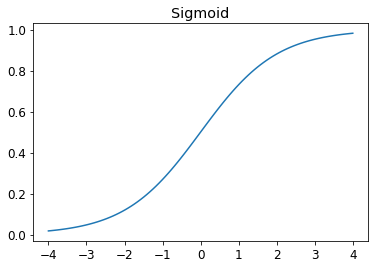

In [ ]:
plot_function(torch.sigmoid, title='Sigmoid', min=-4, max=4)

Как вы видите, эта функция принимает любое входное значение, положительное или отрицательное, и преобразует его в выходное значение в диапазоне от 0 до 1.  Это также плавная кривая, которая всегда возрастает, что облегчает алгоритму стохастического градиентного спуска (SGD) поиск значимых градиентов.

Давайте обновим функцию `mnist_loss`, чтобы сначала применить функцию `sigmoid` к входным данным:


In [ ]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

Теперь мы можем быть уверены, что наша функция потерь будет работать, даже если прогнозы не находятся в диапазоне от 0 до 1. Важно лишь, чтобы более высокий прогноз соответствовал большей уверенности в том, что изображение принадлежит к классу "3".

Определив функцию потерь, сейчас хорошее время, чтобы еще раз напомнить, зачем мы это сделали. В конце концов, у нас уже была метрика, которая измеряла общую точность. Так почему же мы определили функцию потерь?

Ключевое отличие заключается в том, что метрика предназначена для понимания человеком, а функция потерь – для автоматизированного обучения. Для автоматизированного обучения функция потерь должна быть функцией, имеющей осмысленную производную. Она не может иметь больших плоских участков и резких скачков, а должна быть достаточно гладкой. Именно поэтому мы разработали функцию потерь, которая реагирует на небольшие изменения уровня уверенности. Это требование означает, что иногда она не совсем точно отражает то, чего мы пытаемся достичь, а скорее является компромиссом между нашей реальной целью и функцией, которую можно оптимизировать с помощью ее градиента. Функция потерь вычисляется для каждого элемента в нашем наборе данных, а затем, в конце каждой эпохи, все значения потерь усредняются, и среднее значение сообщается для данной эпохи.

Метрики, с другой стороны, – это числа, которые действительно важны для нас. Это значения, которые выводятся в конце каждой эпохи и показывают, насколько хорошо работает наша модель. Важно, чтобы мы научились обращать внимание на эти метрики, а не на функцию потерь, при оценке производительности модели.

### Градиентный спуск (SGD) и мини-пакеты


Теперь, когда у нас есть функция потерь, подходящая для алгоритма стохастического градиентного спуска (SGD), мы можем рассмотреть некоторые детали, связанные со следующим этапом процесса обучения, а именно с изменением или обновлением весов на основе градиентов. Это называется *шагом оптимизации*.

Чтобы выполнить шаг оптимизации, нам нужно рассчитать значение потерь для одного или нескольких элементов данных. Сколько их нужно использовать? Мы могли бы рассчитать значение потерь для всего набора данных и взять среднее, или мы могли бы рассчитать его для одного элемента данных. Но ни один из этих вариантов не является идеальным. Расчет для всего набора данных займет очень много времени. Расчет для одного элемента данных не использует много информации, поэтому он приведет к очень неточному и нестабильному градиенту. То есть, вы будете тратить время и ресурсы на обновление весов, но будете учитывать только то, как это улучшит производительность модели на этом одном элементе данных.

Поэтому мы находим компромисс между этими двумя вариантами: мы рассчитываем среднее значение потерь для нескольких элементов данных одновременно. Это называется *мини-пакетом*. Количество элементов данных в мини-пакете называется *размером пакета*. Больший размер пакета означает, что вы получите более точную и стабильную оценку градиентов вашего набора данных на основе функции потерь, но это займет больше времени, и вы обработаете меньше мини-пакетов за эпоху. Выбор подходящего размера пакета – одно из решений, которое вам необходимо принимать как специалисту в области глубокого обучения, чтобы быстро и точно обучать вашу модель. Мы будем говорить о том, как сделать этот выбор, на протяжении всей этой книги.

Еще одна важная причина использования мини-пакетов, а не расчета градиента для отдельных элементов данных, заключается в том, что на практике мы почти всегда выполняем обучение на ускорителях, таких как графические процессоры (GPU). Эти ускорители работают эффективно только в том случае, если у них есть много задач для выполнения одновременно, поэтому полезно, если мы можем предоставить им много элементов данных для обработки. Использование мини-пакетов – один из лучших способов сделать это. Однако, если вы предоставите им слишком много данных для обработки одновременно, у них закончится память – и даже "удовольствие" графических процессоров нужно добывать с трудом!

Как мы видели в обсуждении техник расширения данных в главе "<<chapter_production>>", мы получаем лучшую обобщающую способность, если мы можем варьировать параметры во время обучения. Одно простое и эффективное изменение, которое мы можем внести, – это изменение набора элементов данных, которые мы помещаем в каждый мини-пакет. Вместо того, чтобы просто перечислять элементы нашего набора данных в порядке для каждой эпохи, мы обычно делаем следующее: мы случайным образом перемешиваем набор данных перед созданием мини-пакетов. PyTorch и fastai предоставляют класс, который выполняет перемешивание и формирование мини-пакетов, который называется `DataLoader`.

Класс `DataLoader` может принимать любую коллекцию Python и преобразовывать ее в итератор мини-пакетов, например:


In [ ]:
coll = range(15)
dl = DataLoader(coll, batch_size=5, shuffle=True)
list(dl)

[tensor([ 3, 12,  8, 10,  2]),
 tensor([ 9,  4,  7, 14,  5]),
 tensor([ 1, 13,  0,  6, 11])]

Для обучения модели нам не просто нужен любой набор данных на Python, а набор, содержащий независимые и зависимые переменные (то есть, входные данные и целевые значения модели). Набор данных, содержащий кортежи независимых и зависимых переменных, в PyTorch называется `Dataset`. Вот пример крайне простого `Dataset`:


In [ ]:
ds = L(enumerate(string.ascii_lowercase))
ds

(#26) [(0, 'a'),(1, 'b'),(2, 'c'),(3, 'd'),(4, 'e'),(5, 'f'),(6, 'g'),(7, 'h'),(8, 'i'),(9, 'j')...]

Когда мы передаем объект `Dataset` в `DataLoader`, мы получаем мини-пакеты, которые сами по себе являются кортежами, содержащими тензоры, представляющие собой пакеты независимых и зависимых переменных:


In [ ]:
dl = DataLoader(ds, batch_size=6, shuffle=True)
list(dl)

[(tensor([17, 18, 10, 22,  8, 14]), ('r', 's', 'k', 'w', 'i', 'o')),
 (tensor([20, 15,  9, 13, 21, 12]), ('u', 'p', 'j', 'n', 'v', 'm')),
 (tensor([ 7, 25,  6,  5, 11, 23]), ('h', 'z', 'g', 'f', 'l', 'x')),
 (tensor([ 1,  3,  0, 24, 19, 16]), ('b', 'd', 'a', 'y', 't', 'q')),
 (tensor([2, 4]), ('c', 'e'))]

Теперь мы готовы написать первый цикл обучения для модели, используя метод стохастического градиентного спуска (SGD)!

## Объединяем все вместе.


Пришло время реализовать процесс, который мы видели в разделе <<gradient_descent>>. В коде наш процесс будет реализован примерно следующим образом для каждой эпохи:

```python
for x, y in dl:
    pred = model(x)
    loss = loss_func(pred, y)
    loss.backward()
    parameters -= parameters.grad * lr
```

Во-первых, давайте перезапустим наши параметры:


In [ ]:
weights = init_params((28*28,1))
bias = init_params(1)

Объект `DataLoader` можно создать на основе объекта `Dataset`:


In [ ]:
dl = DataLoader(dset, batch_size=256)
xb,yb = first(dl)
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

Мы сделаем то же самое для набора данных для проверки:


In [ ]:
valid_dl = DataLoader(valid_dset, batch_size=256)

Давайте создадим мини-пакет размером 4 элемента для тестирования:


In [ ]:
batch = train_x[:4]
batch.shape

torch.Size([4, 784])

In [ ]:
preds = linear1(batch)
preds

tensor([[-11.1002],
        [  5.9263],
        [  9.9627],
        [ -8.1484]], grad_fn=<AddBackward0>)

In [ ]:
loss = mnist_loss(preds, train_y[:4])
loss

tensor(0.5006, grad_fn=<MeanBackward0>)

Теперь мы можем вычислить градиенты:


In [ ]:
loss.backward()
weights.grad.shape,weights.grad.mean(),bias.grad

(torch.Size([784, 1]), tensor(-0.0001), tensor([-0.0008]))

Давайте объединим все это в функцию:


In [ ]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

и протестируйте это:

In [ ]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0002), tensor([-0.0015]))

Но посмотрите, что произойдет, если мы вызовем эту функцию дважды:


In [ ]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0003), tensor([-0.0023]))

Градиенты изменились! Причина этого заключается в том, что функция `loss.backward` фактически *добавляет* градиенты функции `loss` к градиентам, которые уже хранятся. Поэтому, нам нужно сначала установить текущие градиенты в 0:


In [ ]:
weights.grad.zero_()
bias.grad.zero_();

>Примечание: Операции "на месте": Методы в PyTorch, имена которых заканчиваются символом подчеркивания, изменяют свои объекты непосредственно, "на месте". Например, `bias.zero_()` устанавливает все элементы тензора `bias` в значение 0.

Наш следующий и последний шаг – обновить веса и смещения, используя градиент и скорость обучения. При этом необходимо указать PyTorch, чтобы он не вычислял градиент и для этого шага, иначе возникнут серьезные затруднения при вычислении производной для следующей порции данных! Если мы присваиваем значение атрибуту `data` тензора, то PyTorch не будет вычислять градиент для этого шага. Вот наша основная структура цикла обучения для одной эпохи:


In [ ]:
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

Мы также хотим оценить нашу работу, проанализировав точность на проверочном наборе данных. Чтобы определить, представляет ли выходное значение цифру 3 или 7, мы можем просто проверить, больше ли оно, чем 0. Таким образом, точность для каждого элемента можно рассчитать (используя механизм "трансляции", чтобы избежать циклов) следующим образом:


In [ ]:
(preds>0.0).float() == train_y[:4]

tensor([[False],
        [ True],
        [ True],
        [False]])

Это позволяет нам использовать следующую функцию для расчета точности нашей модели при проверке:


In [ ]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

Мы можем проверить, работает ли это:


In [ ]:
batch_accuracy(linear1(batch), train_y[:4])

tensor(0.5000)

затем объедините полученные партии:

In [ ]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [ ]:
validate_epoch(linear1)

0.5219

Это наша отправная точка. Давайте обучим модель в течение одной эпохи и посмотрим, улучшится ли точность:

In [ ]:
lr = 1.
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.6883

Затем выполните еще несколько заданий:


In [ ]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.8314 0.9017 0.9227 0.9349 0.9438 0.9501 0.9535 0.9564 0.9594 0.9618 0.9613 0.9638 0.9643 0.9652 0.9662 0.9677 0.9687 0.9691 0.9691 0.9696 

Отлично! Мы уже достигли примерно той же точности, что и при использовании подхода "сравнения пикселей", и создали универсальную основу, на которой можно развиваться. Следующий шаг – создать объект, который будет выполнять для нас этап стохастической градиентной оптимизации (SGD). В PyTorch этот объект называется *оптимизатором*.

### Создание оптимизатора


Поскольку это очень общая основа, PyTorch предоставляет несколько полезных классов, которые упрощают процесс реализации. Первое, что мы можем сделать, это заменить нашу функцию `linear1` модулем `nn.Linear` из PyTorch. *Модуль* – это объект класса, который наследуется от класса `nn.Module` в PyTorch. Объекты этого класса ведут себя аналогично стандартным функциям Python: вы можете вызывать их, используя круглые скобки, и они возвращают значения активаций модели.

Модуль `nn.Linear` выполняет ту же функцию, что и наши функции `init_params` и `linear` вместе. Он содержит как *веса*, так и *смещения* в одном классе. Вот как мы можем воссоздать нашу модель из предыдущего раздела:


In [ ]:
linear_model = nn.Linear(28*28,1)

Каждый модуль PyTorch знает, какие параметры он содержит и которые могут быть обучены. К ним можно получить доступ через метод `parameters`:


In [ ]:
w,b = linear_model.parameters()
w.shape,b.shape

(torch.Size([1, 784]), torch.Size([1]))

Мы можем использовать эту информацию для создания оптимизатора:


In [ ]:
class BasicOptim:
    def __init__(self,params,lr): self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

Мы можем создать оптимизатор, передав ему параметры модели:


In [ ]:
opt = BasicOptim(linear_model.parameters(), lr)

Наш цикл обучения теперь можно упростить до следующего:


In [ ]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

Наша функция проверки не требует никаких изменений:


In [ ]:
validate_epoch(linear_model)

0.4157

Давайте поместим наш небольшой цикл обучения в функцию, чтобы упростить процесс:


In [ ]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

Результаты совпадают с результатами, представленными в предыдущем разделе:


In [ ]:
train_model(linear_model, 20)

0.4932 0.8618 0.8203 0.9102 0.9331 0.9468 0.9555 0.9629 0.9658 0.9673 0.9687 0.9707 0.9726 0.9751 0.9761 0.9761 0.9775 0.978 0.9785 0.9785 

Библиотека fastai предоставляет класс `SGD`, который, по умолчанию, выполняет ту же функцию, что и наш класс `BasicOptim`:


In [ ]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.4932 0.852 0.8335 0.9116 0.9326 0.9473 0.9555 0.9624 0.9648 0.9668 0.9692 0.9712 0.9731 0.9746 0.9761 0.9765 0.9775 0.978 0.9785 0.9785 

Библиотека fastai также предоставляет функцию `Learner.fit`, которую можно использовать вместо `train_model`. Для создания объекта `Learner` сначала необходимо создать объект `DataLoaders`, передав ему объекты `DataLoader` для обучения и валидации:


In [ ]:
dls = DataLoaders(dl, valid_dl)

Чтобы создать объект `Learner` без использования приложения (например, `vision_learner`), нам необходимо передать все элементы, которые мы создали в этой главе: `DataLoaders`, модель, функцию оптимизации (которая будет получать параметры), функцию потерь и, опционально, любые метрики, которые нужно вывести.

In [ ]:
learn = Learner(dls, nn.Linear(28*28,1), opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

Теперь мы можем вызвать функцию `fit`:


In [ ]:
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.636857,0.503549,0.495584,00:00
1,0.545725,0.170281,0.866045,00:00
2,0.199223,0.184893,0.831207,00:00
3,0.086580,0.107836,0.911187,00:00
4,0.045185,0.078481,0.932777,00:00
5,0.029108,0.062792,0.946516,00:00
6,0.022560,0.053017,0.955348,00:00
7,0.019687,0.046500,0.962218,00:00
8,0.018252,0.041929,0.965162,00:00
9,0.017402,0.038573,0.967615,00:00


Как вы видите, в классах PyTorch и fastai нет ничего волшебного. Это просто удобные, готовые компоненты, которые немного упрощают вашу работу! (Они также предоставляют множество дополнительных функций, которые мы будем использовать в будущих главах.)

С помощью этих классов мы теперь можем заменить нашу линейную модель на нейронную сеть.

## Добавление нелинейности


На данный момент у нас есть общая процедура для оптимизации параметров функции, и мы опробовали ее на очень простой функции: линейном классификаторе. Линейный классификатор имеет очень ограниченные возможности. Чтобы сделать его немного сложнее (и чтобы он мог решать больше задач), нам нужно добавить нелинейный элемент между двумя линейными классификаторами – это и есть нейронная сеть.

Вот полное определение базовой нейронной сети:


In [ ]:
def simple_net(xb): 
    res = xb@w1 + b1
    res = res.max(tensor(0.0))
    res = res@w2 + b2
    return res

Вот и все! В `simple_net` у нас всего две линейные классификаторы, между которыми находится функция `max`.

Здесь `w1` и `w2` – это тензоры весов, а `b1` и `b2` – это тензоры смещений; то есть, параметры, которые изначально инициализируются случайным образом, как мы делали в предыдущем разделе:


In [ ]:
w1 = init_params((28*28,30))
b1 = init_params(30)
w2 = init_params((30,1))
b2 = init_params(1)

Ключевой момент здесь заключается в том, что `w1` имеет 30 выходных активаций (что означает, что `w2` должна иметь 30 входных активаций, чтобы они совпадали). Это означает, что первый слой может создавать 30 различных признаков, каждый из которых представляет собой определенную комбинацию пикселей. Вы можете изменить это число `30` на любое другое, чтобы сделать модель более или менее сложной.

Эта небольшая функция `res.max(tensor(0.0))` называется *модифицированной линейной единицей*, также известной как *ReLU*. Мы все, вероятно, согласимся, что *модифицированная линейная единица* звучит довольно сложно... Но на самом деле, в ней нет ничего сложного, кроме `res.max(tensor(0.0))` – то есть, заменяем каждое отрицательное число на ноль. Эта крошечная функция также доступна в PyTorch как `F.relu`:


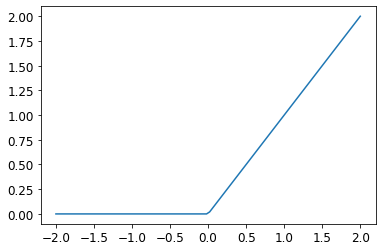

In [ ]:
plot_function(F.relu)

J: В области глубокого обучения используется огромное количество специализированной терминологии, включая такие термины, как "выпрямленная линейная функция". Подавляющее большинство этих терминов не сложнее того, что можно реализовать в нескольких строках кода, как мы видели в этом примере. Фактически, чтобы научные статьи были опубликованы, авторам необходимо, чтобы они звучали максимально впечатляюще и сложно. Один из способов достижения этого – использование специализированной терминологии. К сожалению, это приводит к тому, что эта область становится гораздо более пугающей и сложной для освоения, чем она должна быть. Вам, безусловно, необходимо изучить эту терминологию, иначе научные статьи и учебные материалы будут для вас малопонятны. Но это не означает, что вам нужно воспринимать эту терминологию как что-то пугающее. Просто помните, что когда вы сталкиваетесь со словом или фразой, которые вам незнакомы, скорее всего, они обозначают очень простой концепт.

Основная идея заключается в том, что, используя больше линейных слоев, мы можем заставить нашу модель выполнять больше вычислений и, следовательно, моделировать более сложные функции. Однако, нет смысла просто ставить один линейный слой сразу за другим, потому что, когда мы умножаем числа и затем складываем их многократно, это можно заменить умножением разных чисел друг на друга и сложением их всего один раз! Другими словами, последовательность любого количества линейных слоев может быть заменена одним линейным слоем с другим набором параметров.

Однако, если мы поместим между ними нелинейную функцию, например, `max`, то это утверждение перестает быть верным. Теперь каждый линейный слой в некоторой степени становится независимым от остальных и может выполнять свою полезную работу. Функция `max` особенно интересна, поскольку она действует как простое условное выражение.

Вот перевод:

> S: Математически мы говорим, что композиция двух линейных функций является еще одной линейной функцией. Следовательно, мы можем разместить столько линейных классификаторов друг над другом, сколько захотим, и если между ними нет нелинейных функций, это будет эквивалентно одному линейному классификатору.

Удивительно, но математически доказано, что эта простая функция может решить любую вычислимую задачу с произвольно высокой точностью, при условии, что вы сможете найти правильные параметры для `w1` и `w2`, и если вы сделаете эти матрицы достаточно большими. Для любой произвольно сложной функции мы можем аппроксимировать ее, объединив множество прямых линий; чтобы аппроксимация была ближе к исходной функции, нам просто нужно использовать более короткие линии. Это известно как *теорема об универсальной аппроксимации*. Три строки кода, которые мы видим здесь, называются *слоями*. Первая и третья строки называются *линейными слоями*, а вторая строка кода может называться по-разному: *нелинейностью* или *функцией активации*.

Как и в предыдущем разделе, мы можем заменить этот код на что-то немного более простое, используя возможности PyTorch:


In [ ]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

`nn.Sequential` создает модуль, который последовательно вызывает каждый из указанных слоев или функций.

`nn.ReLU` – это модуль PyTorch, который делает то же самое, что и функция `F.relu`. Большинство функций, которые могут быть использованы в модели, также имеют идентичные формы, представленные в виде модулей. Как правило, это просто замена `F` на `nn` и изменение регистра букв. При использовании `nn.Sequential` PyTorch требует от нас использования модульной версии. Поскольку модули являются классами, мы должны создавать их экземпляры, поэтому в этом примере вы видите `nn.ReLU()`.

Поскольку `nn.Sequential` является модулем, мы можем получить доступ к его параметрам, которые вернут список всех параметров всех модулей, входящих в его состав. Давайте попробуем! Поскольку это более сложная модель, мы будем использовать более низкую скорость обучения и немного больше эпох.

In [ ]:
learn = Learner(dls, simple_net, opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [ ]:
#hide_output
learn.fit(40, 0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.305828,0.399663,0.508341,00:00
1,0.142960,0.225702,0.807655,00:00
2,0.079516,0.113519,0.919529,00:00
3,0.052391,0.076792,0.943081,00:00
4,0.039796,0.060083,0.956330,00:00
5,0.033368,0.050713,0.963690,00:00
6,0.029680,0.044797,0.965653,00:00
7,0.027290,0.040729,0.968106,00:00
8,0.025568,0.037771,0.968597,00:00
9,0.024233,0.035508,0.970559,00:00


Мы не приводим здесь 40 строк вывода, чтобы сэкономить место; процесс обучения записывается в файле `learn.recorder`, а таблица результатов хранится в атрибуте `values`, поэтому мы можем построить график точности в зависимости от этапа обучения, как показано ниже:


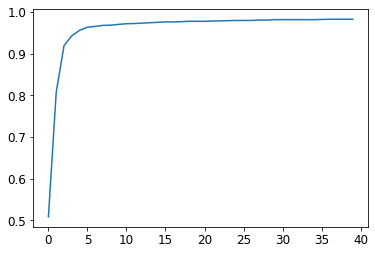

In [ ]:
plt.plot(L(learn.recorder.values).itemgot(2));

И мы можем посмотреть на итоговую точность:


In [ ]:
learn.recorder.values[-1][2]

0.982826292514801

На данном этапе у нас есть нечто, что можно назвать настоящим чудом:

1.  Функция, способная решить любую задачу с любой степенью точности (нейронная сеть), при условии правильного набора параметров.
2.  Способ найти оптимальный набор параметров для любой функции (стохастический градиентный спуск).

Именно поэтому глубокое обучение может выполнять вещи, которые кажутся почти волшебными, такие замечательные вещи. Вера в то, что эта комбинация простых методов действительно может решить любую задачу, – один из самых важных шагов, которые, как мы видим, многим студентам приходится делать. Это кажется слишком хорошим, чтобы быть правдой: не должны ли вещи быть более сложными и запутанными? Наша рекомендация: попробуйте сами! Мы только что опробовали это на наборе данных MNIST, и вы увидели результаты. И поскольку мы делаем все сами, с нуля (за исключением расчета градиентов), вы можете быть уверены, что за всем этим нет никакой особой магии, скрытой "под капотом".

### Углубляемся в тему.

Не обязательно ограничиваться всего двумя линейными слоями. Мы можем добавить столько, сколько захотим, при условии, что между каждой парой линейных слоев мы добавляем нелинейный элемент. Однако, как вы узнаете, чем глубже становится модель, тем сложнее становится оптимизировать ее параметры на практике. Позже, в этой книге, вы узнаете о некоторых простых, но очень эффективных методах обучения более глубоких моделей.

Мы уже знаем, что одного нелинейного элемента и двух линейных слоев достаточно для аппроксимации любой функции. Так зачем же нам нужны более глубокие модели? Причина в производительности. С более глубокой моделью (то есть с большим количеством слоев) нам не нужно использовать такое большое количество параметров; оказывается, что мы можем использовать более компактные матрицы с большим количеством слоев, и получить лучшие результаты, чем если бы мы использовали большие матрицы и небольшое количество слоев.

Это означает, что мы можем обучать модель быстрее, и она будет занимать меньше памяти. В 1990-х годах исследователи были настолько сосредоточены на теореме об универсальной аппроксимации, что очень немногие экспериментировали с более чем одним нелинейным элементом. Этот теоретический, но непрактичный подход тормозил развитие этой области на протяжении многих лет. Однако некоторые исследователи все же экспериментировали с глубокими моделями и, в конечном итоге, смогли показать, что эти модели могут показывать гораздо лучшие результаты на практике. В конце концов, были разработаны теоретические результаты, объясняющие, почему это происходит. Сегодня крайне редко можно встретить нейронную сеть, использующую всего один нелинейный элемент.

Вот что происходит, когда мы обучаем модель с 18 слоями, используя тот же подход, который мы видели во введении к главе:


In [ ]:
dls = ImageDataLoaders.from_folder(path)
learn = vision_learner(dls, resnet18, pretrained=False,
                    loss_func=F.cross_entropy, metrics=accuracy)
learn.fit_one_cycle(1, 0.1)

epoch,train_loss,valid_loss,accuracy,time
0,0.082089,0.009578,0.997056,00:11


Практически 100% точности! Это огромная разница по сравнению с нашей простой нейронной сетью. Но, как вы узнаете из оставшейся части этой книги, для достижения таких отличных результатов с нуля вам потребуется использовать всего несколько небольших приемов. Вы уже знакомы с основными принципами. (Конечно, даже когда вы освоите все эти приемы, вам почти всегда будет удобнее работать с готовыми классами, предоставляемыми PyTorch и fastai, поскольку они избавляют вас от необходимости самостоятельно думать обо всех этих мелочах.)

## Краткий обзор терминологии.

Поздравляем: теперь вы знаете, как создавать и обучать глубокую нейронную сеть с нуля! Мы прошли немало этапов, чтобы достичь этой точки, но, возможно, вы будете удивлены тем, насколько это на самом деле просто.

Теперь, когда мы достигли этого этапа, это отличная возможность определить и повторить некоторые специальные термины и ключевые концепции.

Нейронная сеть содержит много чисел, но они бывают только двух типов: числа, которые вычисляются, и параметры, из которых эти числа вычисляются. Это дает нам два самых важных термина, которые необходимо знать:

- Активации: числа, которые вычисляются (как линейными, так и нелинейными слоями).
- Параметры: числа, которые инициализируются случайным образом и оптимизируются (то есть числа, которые определяют модель).

В этой книге мы часто будем говорить об активациях и параметрах. Помните, что они имеют очень конкретные значения. Это числа. Это не абстрактные концепции, а конкретные числа, которые находятся в вашей модели. Часть того, чтобы стать хорошим специалистом в области глубокого обучения, заключается в том, чтобы привыкнуть к тому, чтобы действительно смотреть на ваши активации и параметры, строить их графики и проверять, правильно ли они работают.

Все наши активации и параметры содержатся в *тензорах*. Это просто массивы определенной структуры, например, матрица. Матрицы имеют строки и столбцы, которые мы называем *осями* или *измерениями*. Число измерений тензора — это его *ранг*. Существуют некоторые специальные тензоры:

- Ранг 0: скаляр.
- Ранг 1: вектор.
- Ранг 2: матрица.

Нейронная сеть содержит несколько слоев. Каждый слой является либо *линейным*, либо *нелинейным*. В нейронной сети мы обычно чередуем эти два типа слоев. Иногда линейный слой и последующая нелинейность объединяются в один слой. Да, это может быть запутанно. Иногда нелинейность называют *функцией активации*.

<<dljargon1>> содержит ключевые концепции, связанные с градиентным спуском (SGD).

```asciidoc
[[dljargon1]]
.Словарь глубокого обучения
[options="header"]
|=====
| Термин | Значение
|ReLU | Функция, которая возвращает 0 для отрицательных чисел и не изменяет положительные числа.
|Мини-пакет (Mini-batch) | Небольшая группа входных данных и меток, объединенных в два массива. Шаг градиентного спуска выполняется на этом пакете (а не на всей эпохе).
|Прямой проход (Forward pass) | Применение модели к входным данным и вычисление прогнозов.
|Функция потерь (Loss) | Значение, которое показывает, насколько хорошо (или плохо) работает наша модель.
|Градиент | Производная функции потерь по отношению к некоторому параметру модели.
|Обратный проход (Backward pass) | Вычисление градиентов функции потерь по отношению ко всем параметрам модели.
|Градиентный спуск (Gradient descent) | Шаг в направлении, противоположном градиентам, для улучшения параметров модели.
|Скорость обучения (Learning rate) | Размер шага, который мы делаем при применении SGD для обновления параметров модели.
|=====
```

> Обратите внимание: _Интерактивная история: Выбирайте свой путь_. Напоминание: вы, возможно, захотели сразу "заглянуть под капот" и пропустили главы 2 и 3? Вот ваше напоминание вернуться к главе 2 прямо сейчас, потому что вам очень скоро понадобится эта информация!

## Анкета


1. Как представляется изображение в градациях серого на компьютере? А цветное изображение?
1. Как структурированы файлы и папки в наборе данных `MNIST_SAMPLE`? Почему?
1. Объясните, как работает подход "сравнение пикселей" для классификации цифр.
1. Что такое списочное включение (list comprehension)? Создайте его сейчас, чтобы выбрать нечетные числа из списка и умножить их на два.
1. Что такое "тензор ранга 3"?
1. В чем разница между рангом тензора и его формой? Как получить ранг из формы?
2. Что такое среднеквадратичная ошибка (RMSE) и норма L1?
3. Как можно выполнить вычисления над тысячами чисел одновременно, во много тысяч раз быстрее, чем при использовании цикла Python?
4. Создайте тензор или массив 3x3, содержащий числа от 1 до 9. Удвойте его. Выберите четыре числа из нижнего правого угла.
5. Что такое "трансляция" (broadcasting)?
6. Обычно метрики вычисляются на обучающем наборе данных или на наборе данных для валидации? Почему?
7. Что такое стохастический градиентный спуск (SGD)?
8. Почему SGD использует мини-пакеты (mini-batches)?
9. Каковы семь этапов SGD для машинного обучения?
10. Как мы инициализируем веса в модели?
11. Что такое "потеря" (loss)?
12. Почему мы не всегда можем использовать высокую скорость обучения?
13. Что такое "градиент"?
14. Нужно ли вам уметь самостоятельно вычислять градиенты?
15. Почему мы не можем использовать точность (accuracy) в качестве функции потерь?
16. Нарисуйте сигмоидальную функцию. Что особенного в ее форме?
17. В чем разница между функцией потерь и метрикой?
18. Какая функция используется для вычисления новых весов с использованием скорости обучения?
19. Что делает класс `DataLoader`?
20. Напишите псевдокод, показывающий основные шаги, выполняемые на каждой эпохе для SGD.
21. Создайте функцию, которая, если ей переданы аргументы `[1, 2, 3, 4]` и `'abcd'`, возвращает `[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]`. Что особенного в этой структуре данных?
22. Что делает функция `view` в PyTorch?
23. Что такое параметры "смещения" (bias) в нейронной сети? Зачем они нужны?
24. Что делает оператор `@` в Python?
25. Что делает метод `backward`?
26. Почему нам нужно обнулять градиенты?
27. Какую информацию мы должны передавать классу `Learner`?
28. Приведите пример кода на Python или псевдокод, показывающий основные шаги цикла обучения.
29. Что такое "ReLU"? Нарисуйте график этой функции для значений от `-2` до `+2`.
30. Что такое "функция активации"?
31. В чем разница между `F.relu` и `nn.ReLU`?
32. Теорема об универсальной аппроксимации показывает, что любую функцию можно аппроксимировать с любой необходимой точностью, используя только одну нелинейность. Так почему мы обычно используем больше?

### Дальнейшие исследования


1. Создайте собственную реализацию класса `Learner` с нуля, основываясь на цикле обучения, показанном в этой главе.
2. Выполните все шаги, описанные в этой главе, используя полный набор данных MNIST (то есть, для всех цифр, а не только для цифр 3 и 7). Это серьезный проект, и его выполнение займет у вас немало времени! Вам потребуется провести собственные исследования, чтобы понять, как преодолеть некоторые трудности, с которыми вы столкнетесь в процессе.